<a href="https://colab.research.google.com/github/m-gian/handson-ml3/blob/main/ML_Hands_On.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Eigen Vector & Eigen Values

***Step-1: Compute Eigenvalues & Eigenvectors in Python***

In [ ]:
import numpy as np

A = np.array([[2, 1],
              [1, 2]])

# Compute eigenvalues and eigenvectors
eig_vals, eig_vecs = np.linalg.eig(A)

print("Eigenvalues:\n", eig_vals)
print("\nEigenvectors:\n", eig_vecs)


Eigenvalues:
 [3. 1.]

Eigenvectors:
 [[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]


**Step-2: Verify the Eigenvector Property => Check: Av=λv**

In [ ]:
v = eig_vecs[:, 0]      # eigenvector for eigenvalue 3
lambda_ = eig_vals[0]

left = A @ v
right = lambda_ * v

print("Av:\n", left)
print("\nλv:\n", right)


Av:
 [2.12132034 2.12132034]

λv:
 [2.12132034 2.12132034]


**Step-3: Visualization**

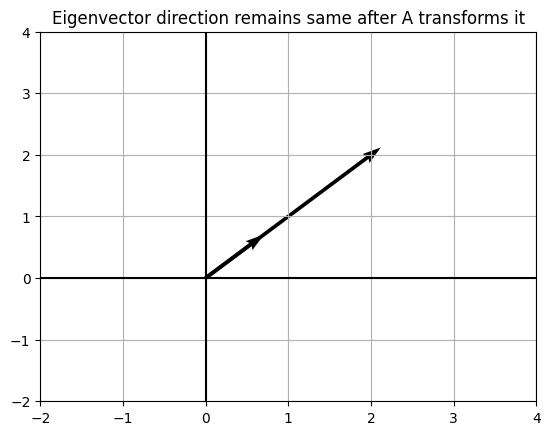

In [ ]:
import matplotlib.pyplot as plt

v = eig_vecs[:, 0]  # eigenvector corresponding to largest eigenvalue

Av = A @ v

plt.axhline(0, color='black')
plt.axvline(0, color='black')

plt.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1, label='v')
plt.quiver(0, 0, Av[0], Av[1], angles='xy', scale_units='xy', scale=1, label='Av')

plt.xlim(-2, 4)
plt.ylim(-2, 4)
plt.grid()
plt.title("Eigenvector direction remains same after A transforms it")
plt.show()


This plot will show:

1. v and Av pointing in the same direction

2. Av is just a scaled version of v → meaning v is an eigenvector

**Step-4: Applying It to Real ML Data (PCA Example)**

In [ ]:
from sklearn.datasets import load_iris
import numpy as np

# load data
X = load_iris().data

# standardize
X_std = (X - X.mean(axis=0)) / X.std(axis=0)

# covariance matrix
cov = np.cov(X_std, rowvar=False)

# eigen decomposition
eig_vals, eig_vecs = np.linalg.eig(cov)

print("Eigenvalues:\n", eig_vals)
print("\nEigenvectors (principal components):\n", eig_vecs)

Eigenvalues:
 [2.93808505 0.9201649  0.14774182 0.02085386]

Eigenvectors (principal components):
 [[ 0.52106591 -0.37741762 -0.71956635  0.26128628]
 [-0.26934744 -0.92329566  0.24438178 -0.12350962]
 [ 0.5804131  -0.02449161  0.14212637 -0.80144925]
 [ 0.56485654 -0.06694199  0.63427274  0.52359713]]


In [ ]:
explained_variance = eig_vals / eig_vals.sum()
explained_variance


array([0.72962445, 0.22850762, 0.03668922, 0.00517871])

Meaning:

1. PC1 explains 72% of variance

2. PC2 explains 23%

3. Others small → reduce dimensionality to 2D

# Gradient Descent

## Batch Gradient Descent

**Step 1 — Generate simple data**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Make reproducible data
np.random.seed(0)

X = np.linspace(0, 10, 50)
y = 3*X + 5 + np.random.randn(50) * 2   # true slope=3, intercept=5

**Step 2 — Initialize parameters**

In [ ]:
m = 0   # slope
c = 0   # intercept
lr = 0.01   # learning rate

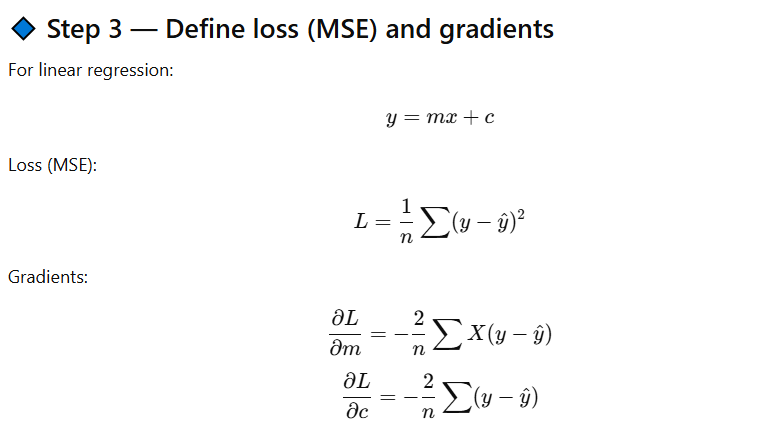

**Step 4 — Implement Gradient Descent Loop**

In [ ]:
losses = []

for epoch in range(500):
    y_pred = m*X + c

    # Compute gradients
    dm = (-2/len(X)) * np.sum(X * (y - y_pred))
    dc = (-2/len(X)) * np.sum(y - y_pred)

    # Update weights
    m = m - lr*dm
    c = c - lr*dc

    # Compute loss
    loss = np.mean((y - y_pred)**2)
    losses.append(loss)

print("Learned slope m:", m)
print("Learned intercept c:", c)


Learned slope m: 2.791232212001275
Learned intercept c: 6.201066048318193


**Step 5 — Plot how loss decreases**

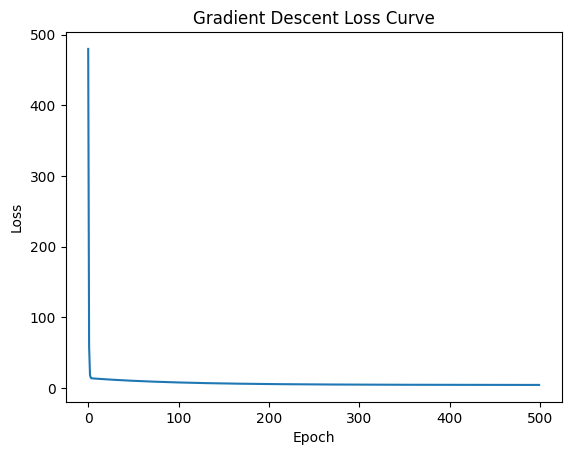

In [ ]:
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Gradient Descent Loss Curve")
plt.show()


**Step 6 — Visualize fitted line**

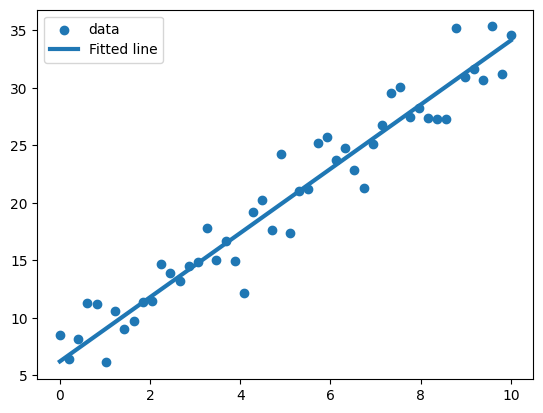

In [ ]:
plt.scatter(X, y, label="data")
plt.plot(X, m*X + c, label="Fitted line", linewidth=3)
plt.legend()
plt.show()


## Stochastic Gradient Descent

In [ ]:
m, c = 0, 0
lr = 0.01
SGD_losses = []

for epoch in range(500):
    i = np.random.randint(0, len(X))
    xi = X[i]
    yi = y[i]

    y_pred = m*xi + c

    dm = -2 * xi * (yi - y_pred)
    dc = -2 * (yi - y_pred)

    m = m - lr*dm
    c = c - lr*dc

    # ---- Full dataset loss tracking ----
    y_full_pred = m*X + c
    loss = np.mean((y - y_full_pred)**2)
    SGD_losses.append(loss)
print("SGD slope:", m)
print("SGD intercept:", c)

SGD slope: 2.6936537800342157
SGD intercept: 5.926430459031139


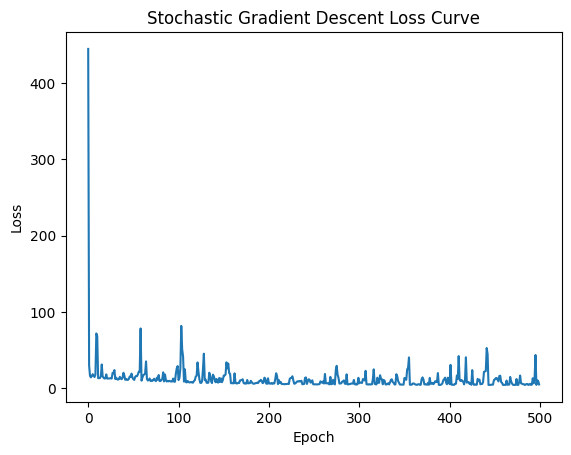

In [ ]:
plt.plot(SGD_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Stochastic Gradient Descent Loss Curve")
plt.show()

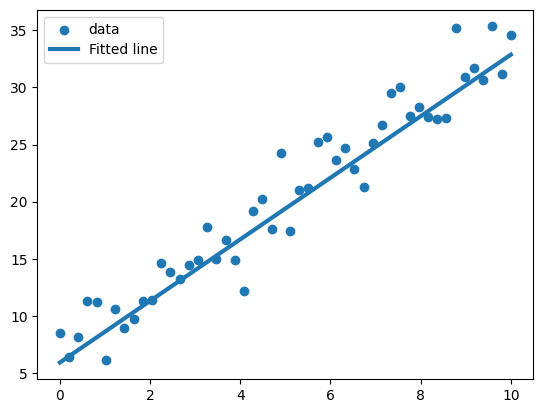

In [ ]:
plt.scatter(X, y, label="data")
plt.plot(X, m*X + c, label="Fitted line", linewidth=3)
plt.legend()
plt.show()

**Mini-Batch Gradient Descent**

In [ ]:
m, c = 0, 0
lr = 0.01
batch_size = 8
mini_batch_losses = []

for epoch in range(300):
    idx = np.random.choice(len(X), batch_size, replace=False)
    Xb = X[idx]
    yb = y[idx]

    y_pred = m*Xb + c

    dm = (-2/batch_size) * np.sum(Xb * (yb - y_pred))
    dc = (-2/batch_size) * np.sum(yb - y_pred)

    m = m - lr*dm
    c = c - lr*dc
    # ---- Full dataset loss tracking ----
    y_full_pred = m*X + c
    loss = np.mean((y - y_full_pred)**2)
    mini_batch_losses.append(loss)

print("Mini-batch slope:", m)
print("Mini-batch intercept:", c)


Mini-batch slope: 2.914169048319134
Mini-batch intercept: 5.426835333653262


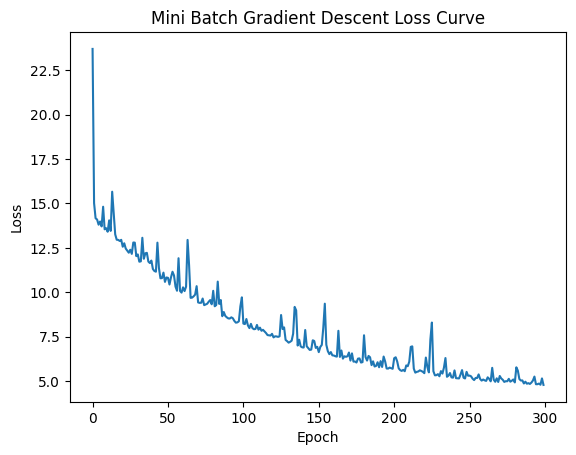

In [ ]:
plt.plot(mini_batch_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Mini Batch Gradient Descent Loss Curve")
plt.show()

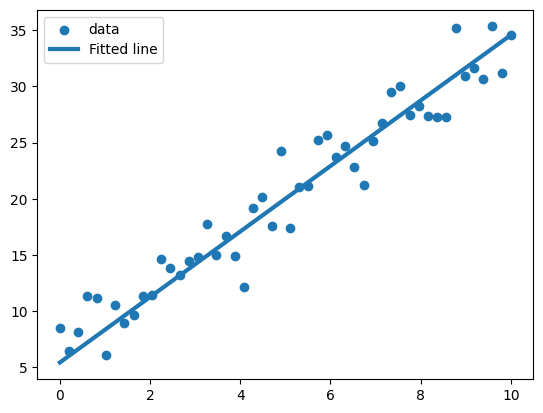

In [ ]:
plt.scatter(X, y, label="data")
plt.plot(X, m*X + c, label="Fitted line", linewidth=3)
plt.legend()
plt.show()

# Underfitting, Balanced, Overfitting Hands-On

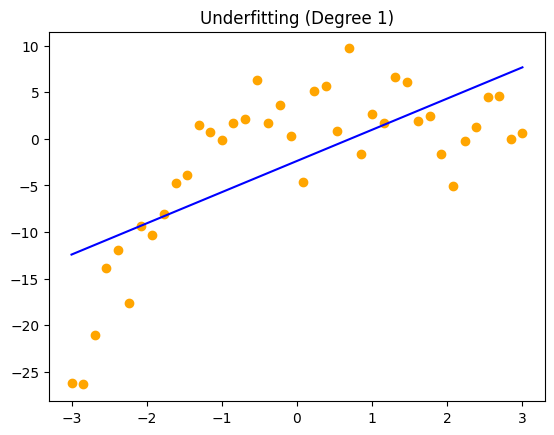

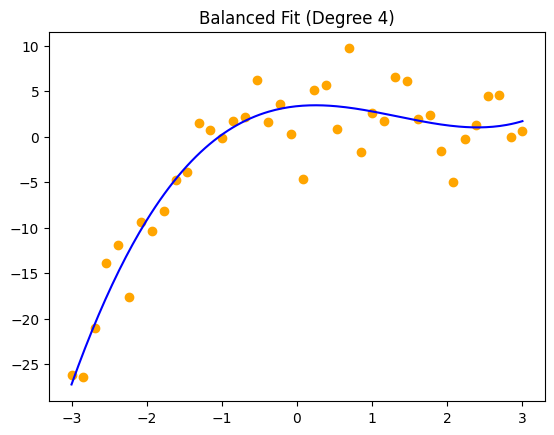

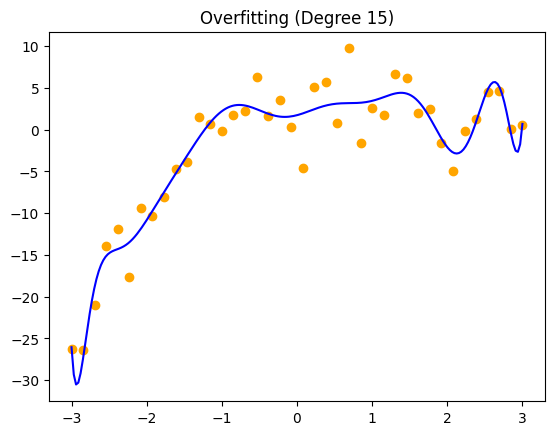

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Create dataset
np.random.seed(0)
X = np.linspace(-3, 3, 40)
y = 0.5 * X**3 - 2*X**2 + X + 3 + np.random.randn(40) * 3
X = X.reshape(-1, 1)

def plot_model(degree, title):
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X)

    model = LinearRegression()
    model.fit(X_poly, y)

    # prediction line
    X_grid = np.linspace(-3, 3, 200).reshape(-1, 1)
    X_grid_poly = poly.transform(X_grid)
    y_pred = model.predict(X_grid_poly)

    plt.scatter(X, y, color='orange')
    plt.plot(X_grid, y_pred, color='blue')
    plt.title(title)
    plt.show()

# Underfit model
plot_model(1, "Underfitting (Degree 1)")

# Balanced model
plot_model(4, "Balanced Fit (Degree 4)")

# Overfit model
plot_model(15, "Overfitting (Degree 15)")


# Train vs Validation Loss Curves (Under/Overfit)

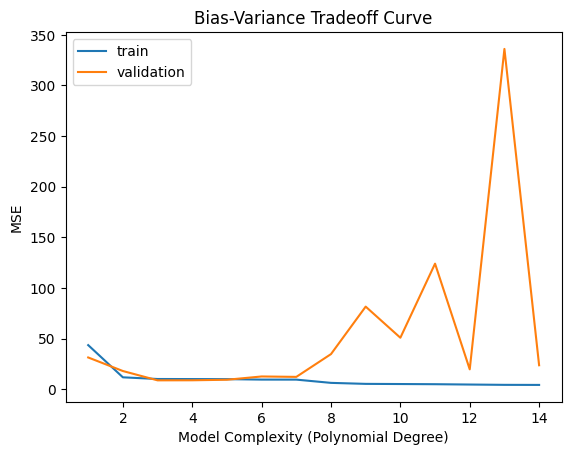

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)

train_errors = []
val_errors = []

degrees = range(1, 15)

for d in degrees:
    poly = PolynomialFeatures(d)
    X_train_poly = poly.fit_transform(X_train)
    X_val_poly = poly.transform(X_val)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    train_pred = model.predict(X_train_poly)
    val_pred = model.predict(X_val_poly)

    train_errors.append(mean_squared_error(y_train, train_pred))
    val_errors.append(mean_squared_error(y_val, val_pred))

plt.plot(degrees, train_errors, label="train")
plt.plot(degrees, val_errors, label="validation")
plt.xlabel("Model Complexity (Polynomial Degree)")
plt.ylabel("MSE")
plt.legend()
plt.title("Bias-Variance Tradeoff Curve")
plt.show()


# Regularization (Ridge, Lasso, ElasticNet)

In [ ]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

poly = PolynomialFeatures(10)
X_poly = poly.fit_transform(X)

ridge = Ridge(alpha=10).fit(X_poly, y)
lasso = Lasso(alpha=0.1).fit(X_poly, y)
elastic = ElasticNet(alpha=0.1, l1_ratio=0.5).fit(X_poly, y)

print("Ridge weights:", ridge.coef_)
print("Lasso weights:", lasso.coef_)
print("ElasticNet weights:", elastic.coef_)


Ridge weights: [ 0.          0.51580257 -0.02133576  0.63383065 -0.57985781 -0.11230014
 -0.07502591  0.02569837  0.03582939 -0.00171728 -0.00254193]
Lasso weights: [ 0.00000000e+00  6.22652936e-01 -3.99010744e-01  4.09028323e-01
 -7.12049560e-01  1.05455954e-02  9.23520664e-02  3.53905675e-03
  1.55864014e-03 -4.71057456e-04 -5.53278655e-04]
ElasticNet weights: [ 0.00000000e+00  6.68972262e-01 -4.05287507e-01  3.94472804e-01
 -7.36963876e-01  1.16353999e-02  9.87407724e-02  3.55491799e-03
  1.25525335e-03 -4.73201812e-04 -5.64755003e-04]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.742e+02, tolerance: 2.958e-01
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.721e+02, tolerance: 2.958e-01
  model = cd_fast.enet_coordinate_descent(


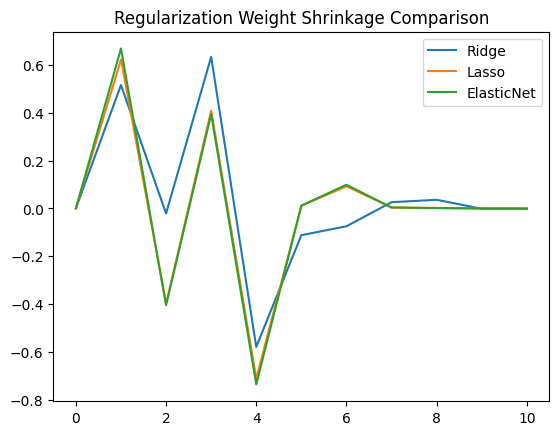

In [ ]:
labels = [f"w{i}" for i in range(len(ridge.coef_))]

plt.plot(ridge.coef_, label="Ridge")
plt.plot(lasso.coef_, label="Lasso")
plt.plot(elastic.coef_, label="ElasticNet")
plt.legend()
plt.title("Regularization Weight Shrinkage Comparison")
plt.show()


Ridge: all weights shrink but stay non-zero

Lasso: many weights become exactly zero → feature selection

ElasticNet: mixture of both

# SHAP Explainability Demo

/tmp/ipython-input-4208162879.py:11: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X)


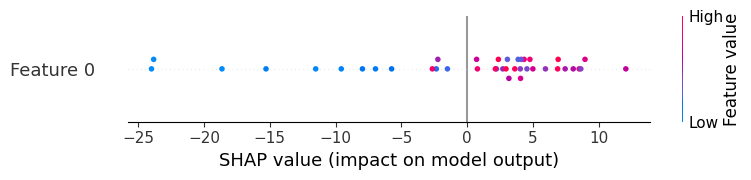

In [ ]:
import shap
import xgboost as xgb

# Fit a simple model
model = xgb.XGBRegressor().fit(X, y)

# SHAP explain
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

shap.summary_plot(shap_values, X)


This tells how much each sample is pushing the model prediction:

Positive SHAP value → pushes prediction up

Negative SHAP value → pushes prediction down

SHAP = 0 → no effect on prediction

So:

✔ Points on the right → feature increases model output
✔ Points on the left → feature decreases model output

Low values of Feature 0 strongly decrease the model’s prediction (big negative SHAP), and high values of Feature 0 increase the prediction (positive SHAP).

/tmp/ipython-input-878777146.py:44: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, plot_type="dot", show=True)


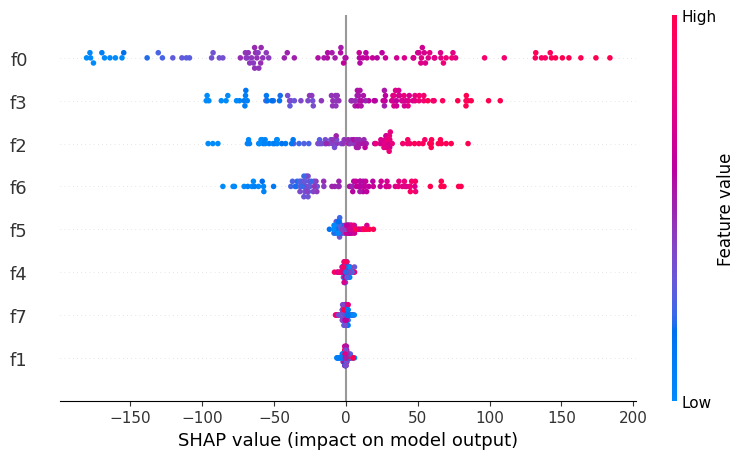

/tmp/ipython-input-878777146.py:48: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, plot_type="bar", show=True)


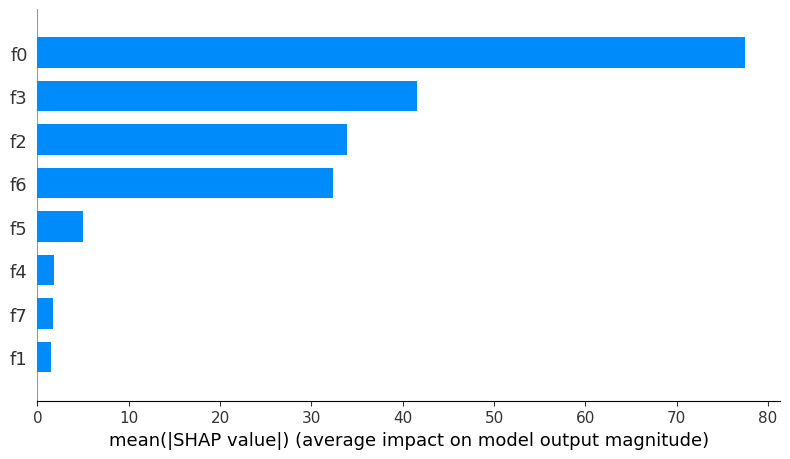

<Figure size 600x400 with 0 Axes>

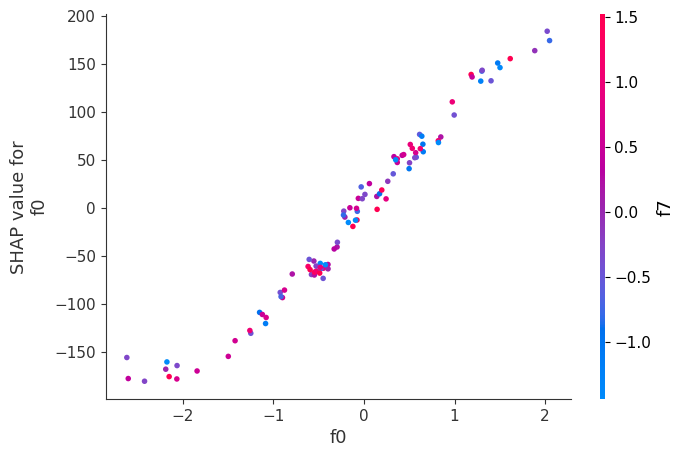

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.datasets import make_regression
from sklearn.ensemble import RandomForestRegressor

# Try XGBoost if available (better trees for SHAP), else RandomForest
try:
    from xgboost import XGBRegressor
    MODEL = 'xgb'
except Exception:
    XGBRegressor = None
    MODEL = 'rf'

# SHAP import
import shap

# Create a synthetic regression dataset with several informative features
X, y = make_regression(n_samples=500, n_features=8, n_informative=5, noise=5, random_state=42)
feature_names = [f"f{i}" for i in range(X.shape[1])]
X = pd.DataFrame(X, columns=feature_names)
y = pd.Series(y, name="target")

# train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit a model (XGBoost if installed, else RandomForest)
if MODEL == 'xgb':
    model = XGBRegressor(n_estimators=100, max_depth=4, random_state=42, verbosity=0)
else:
    model = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42)

model.fit(X_train, y_train)

# Create a SHAP explainer and compute SHAP values
# For tree models: use TreeExplainer for speed/accuracy
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)  # shape: (n_samples, n_features)

# 1) SHAP summary plot (dot plot)
plt.figure(figsize=(8,6))
shap.summary_plot(shap_values, X_test, plot_type="dot", show=True)

# 2) SHAP bar plot (global importance)
plt.figure(figsize=(6,4))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=True)

# 3) Dependence plot for the top feature
# Find top feature by mean(|shap|)
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_idx = np.argmax(mean_abs_shap)
top_feat = X_test.columns[top_idx]

plt.figure(figsize=(6,4))
shap.dependence_plot(top_feat, shap_values, X_test, show=True)



# Model Training

## k-fold CV & LOOCV (classification example)

In [ ]:
# kfold_loocv.ipynb cell
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import cross_val_score, KFold, LeaveOneOut
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load dataset
data = load_iris()
X, y = data.data, data.target

# Model
model = RandomForestClassifier(n_estimators=50, random_state=42)

# 5-fold CV
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')
print("5-fold CV accuracies:", np.round(scores, 3))
print("5-fold CV mean accuracy:", scores.mean())

# LOOCV (only recommended for very small datasets)
loo = LeaveOneOut()
scores_loo = cross_val_score(model, X, y, cv=loo, scoring='accuracy', n_jobs=-1)
print("LOOCV  accuracies:", np.round(scores_loo, 3))
print("LOOCV mean accuracy:", np.round(scores_loo.mean(), 4))


5-fold CV accuracies: [1.    0.967 0.933 0.933 0.967]
5-fold CV mean accuracy: 0.9600000000000002
LOOCV  accuracies: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1.
 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.]
LOOCV mean accuracy: 0.96


## Time Series Cross Validation (expanding & sliding window)

/tmp/ipython-input-3722570911.py:15: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["lag1"] = df["y"].shift(1).fillna(method='bfill')
/tmp/ipython-input-3722570911.py:16: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["lag7"] = df["y"].shift(7).fillna(method='bfill')


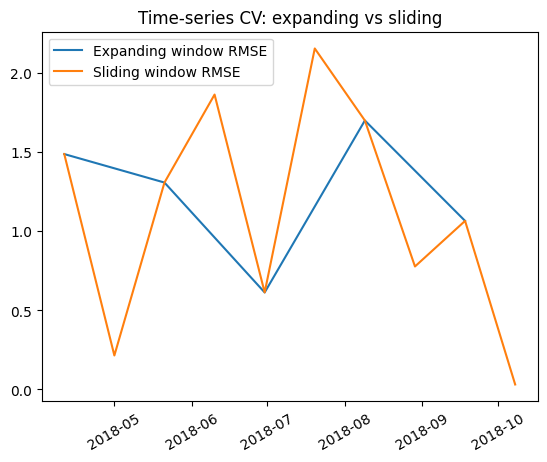

In [ ]:
# timeseries_cv.ipynb cell
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Create synthetic time series data
np.random.seed(42)
n = 300
dates = pd.date_range("2018-01-01", periods=n, freq="D")
t = np.arange(n)
y = 0.05 * t + 2*np.sin(0.1*t) + np.random.normal(scale=1.0, size=n)
df = pd.DataFrame({"date": dates, "y": y})
df["lag1"] = df["y"].shift(1).fillna(method='bfill')
df["lag7"] = df["y"].shift(7).fillna(method='bfill')
features = ["lag1", "lag7"]

# Function: expanding window and sliding window evaluation
def rolling_eval(df, train_size, horizon=1, step=30, expanding=True):
    rmses = []
    indices = []
    start = 0
    while True:
        train_end = start + train_size
        test_start = train_end
        test_end = test_start + horizon
        if test_end > len(df):
            break
        train_idx = range(0, train_end)
        test_idx = range(test_start, test_end)
        X_train = df.iloc[train_idx][features].values
        y_train = df.iloc[train_idx]["y"].values
        X_test = df.iloc[test_idx][features].values
        y_test = df.iloc[test_idx]["y"].values

        model = Ridge()
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        rmse = np.sqrt(mean_squared_error(y_test, pred))
        rmses.append(rmse)
        indices.append(df.iloc[test_idx]["date"].values[0])

        # move window
        if expanding:
            start += step  # add more to training
            train_size += step
        else:
            start += step  # slide window forward (train size fixed)

    return indices, rmses

# Expanding window
dates_exp, rmses_exp = rolling_eval(df, train_size=100, horizon=1, step=20, expanding=True)
# Sliding window (fixed training size)
dates_sl, rmses_sl = rolling_eval(df, train_size=100, horizon=1, step=20, expanding=False)

plt.plot(dates_exp, rmses_exp, label='Expanding window RMSE')
plt.plot(dates_sl, rmses_sl, label='Sliding window RMSE')
plt.xticks(rotation=30)
plt.legend()
plt.title("Time-series CV: expanding vs sliding")
plt.show()


Interpretation: Expanding uses more history each step; sliding treats older data as possibly irrelevant.

## Train / Validation / Test split (large dataset workflow)

In [ ]:
# train_val_test_split.ipynb cell
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

# Load a relatively large dataset
data = fetch_california_housing(as_frame=True)
X = data.data
y = data.target

# Split: Train 70%, Val 10%, Test 20%
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.125, random_state=42)  # 0.125 * 0.8 = 0.10 overall

print("Sizes:", X_train.shape, X_val.shape, X_test.shape)

# Train model on training set, use validation for monitoring
model = GradientBoostingRegressor(random_state=42)
model.fit(X_train, y_train)

# Evaluate
train_pred = model.predict(X_train)
val_pred = model.predict(X_val)
test_pred = model.predict(X_test)
print("Train MSE:", mean_squared_error(y_train, train_pred))
print("Validation MSE:", mean_squared_error(y_val, val_pred))
print("Test MSE (final):", mean_squared_error(y_test, test_pred))


Sizes: (14448, 8) (2064, 8) (4128, 8)
Train MSE: 0.2531592183932296
Validation MSE: 0.2862500529199337
Test MSE (final): 0.29105248015503316


## Bootstrapping (estimate variability) and Bagging (RandomForest)

In [ ]:
# bootstrap_bagging.ipynb cell
import numpy as np
from sklearn.utils import resample
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

# Use California housing subset to keep runtime small
X_train_small, X_test_small, y_train_small, y_test_small = train_test_split(X, y, test_size=0.3, random_state=0)

# Bootstrapping manually: train many trees on bootstrap samples and check variability
n_boot = 30
preds = []
for i in range(n_boot):
    Xb, yb = resample(X_train_small, y_train_small, random_state=i)  # with replacement
    t = DecisionTreeRegressor(max_depth=6, random_state=42)
    t.fit(Xb, yb)
    preds.append(t.predict(X_test_small))

preds = np.array(preds)  # shape (n_boot, n_test)
mean_pred = preds.mean(axis=0)
print("Bootstrap ensemble MSE:", mean_squared_error(y_test_small, mean_pred))
print("Single tree MSE (example):", mean_squared_error(y_test_small, preds[0]))

# Random Forest (bagging + feature randomness)
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_small, y_train_small)
print("RandomForest MSE:", mean_squared_error(y_test_small, rf.predict(X_test_small)))


Bootstrap ensemble MSE: 0.4307831404248673
Single tree MSE (example): 0.5099213472140812
RandomForest MSE: 0.27615097236461267


## Hyperparameter Tuning: GridSearchCV & RandomizedSearchCV

In [ ]:
# hyperparam_tuning.ipynb cell
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from scipy.stats import randint
from sklearn.svm import SVR
import time

X_small = X_train.sample(2000, random_state=42)  # sample to speed up search
y_small = y_train.loc[X_small.index]

svr = SVR()

# Grid search (try a grid)
param_grid = {"C": [0.1, 1, 10], "gamma": ["scale", 0.01, 0.001], "kernel": ["rbf"]}
grid = GridSearchCV(svr, param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
t0 = time.time()
grid.fit(X_small, y_small)
print("Grid best params:", grid.best_params_, "time(s):", round(time.time()-t0,1))
print("Grid best CV RMSE:", (-grid.best_score_)**0.5)

# Randomized search (search wider space)
param_dist = {"C": [0.01, 0.1, 1, 10, 100], "gamma": [0.1, 0.01, 0.001, 'scale'], "kernel": ['rbf']}
rand = RandomizedSearchCV(svr, param_dist, n_iter=8, cv=3, scoring='neg_mean_squared_error', random_state=0, n_jobs=-1)
t1 = time.time()
rand.fit(X_small, y_small)
print("Random best params:", rand.best_params_, "time(s):", round(time.time()-t1,1))
print("Random best CV RMSE:", (-rand.best_score_)**0.5)


Grid best params: {'C': 10, 'gamma': 0.001, 'kernel': 'rbf'} time(s): 14.1
Grid best CV RMSE: 1.0215381929505365
Random best params: {'kernel': 'rbf', 'gamma': 0.001, 'C': 100} time(s): 18.1
Random best CV RMSE: 1.0299709535338766


Rule of thumb: Grid is good for small search spaces; Randomized for larger spaces (faster to explore).

## Training time measurement and scaling

In [ ]:
# training_time.ipynb cell
import time
from sklearn.ensemble import RandomForestRegressor

sizes = [100, 1000, 5000, 20000]  # number of rows to test scaling (ensure dataset large enough)
times = []
for s in sizes:
    if s > X.shape[0]:
        break
    Xt = X.sample(s, random_state=0)
    yt = y.loc[Xt.index]
    model = RandomForestRegressor(n_estimators=50, n_jobs=-1, random_state=0)
    t0 = time.time()
    model.fit(Xt, yt)
    times.append(time.time() - t0)
    print(f"Rows: {s:6d}, train_time: {times[-1]:.2f}s")


Rows:    100, train_time: 0.10s
Rows:   1000, train_time: 0.65s
Rows:   5000, train_time: 3.00s
Rows:  20000, train_time: 21.27s


Note: Training time scales with rows, features, and model complexity (trees, depth, etc.). Use profiling + subsampling and incremental learning where possible.

## Learning Curves

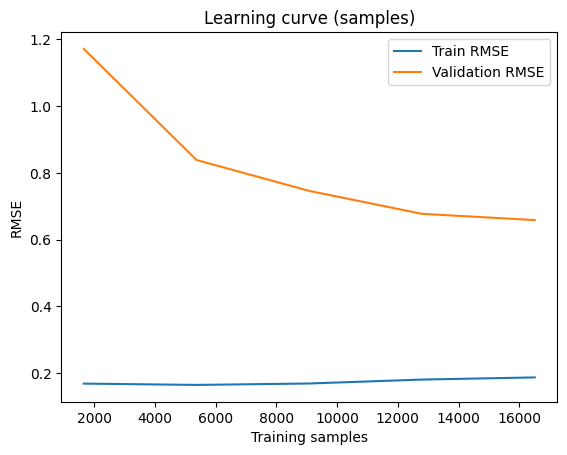

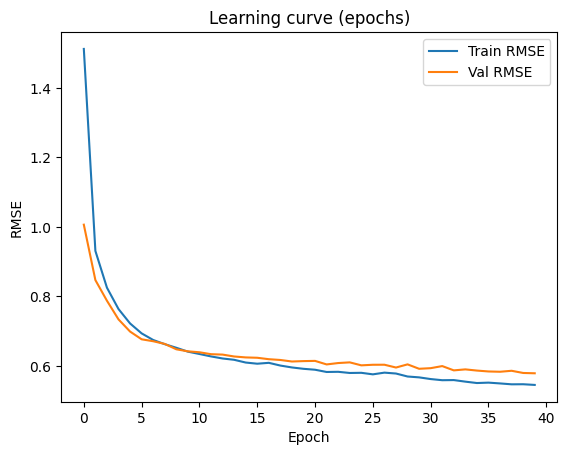

In [ ]:
# learning_curves.ipynb cell
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.ensemble import RandomForestRegressor

# 1) learning curve vs samples
est = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
train_sizes, train_scores, val_scores = learning_curve(est, X, y, cv=5, scoring='neg_mean_squared_error',
                                                       train_sizes=np.linspace(0.1, 1.0, 5), n_jobs=-1)
train_rmse = np.sqrt(-train_scores.mean(axis=1))
val_rmse = np.sqrt(-val_scores.mean(axis=1))

plt.plot(train_sizes, train_rmse, label='Train RMSE')
plt.plot(train_sizes, val_rmse, label='Validation RMSE')
plt.xlabel("Training samples")
plt.ylabel("RMSE")
plt.legend()
plt.title("Learning curve (samples)")
plt.show()

# 2) epochs-based learning curve using Keras
# If running in Colab, TensorFlow is usually preinstalled. If not, !pip install tensorflow
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Prepare small regression dataset
X_nn = X.sample(5000, random_state=0)
y_nn = y.loc[X_nn.index]
X_train_nn, X_val_nn, y_train_nn, y_val_nn = train_test_split(X_nn, y_nn, test_size=0.2, random_state=0)

scaler = StandardScaler()
X_train_nn = scaler.fit_transform(X_train_nn)
X_val_nn = scaler.transform(X_val_nn)

model = models.Sequential([
    layers.Input(shape=(X_train_nn.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])
model.compile(optimizer='adam', loss='mse', metrics=[tf.keras.metrics.RootMeanSquaredError()])

history = model.fit(X_train_nn, y_train_nn, validation_data=(X_val_nn, y_val_nn), epochs=40, batch_size=64, verbose=0)

plt.plot(history.history['root_mean_squared_error'], label='Train RMSE')
plt.plot(history.history['val_root_mean_squared_error'], label='Val RMSE')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.legend()
plt.title('Learning curve (epochs)')
plt.show()


# Linear Regression + MSE + MAE + RMSE (Hands-on)

MSE: 3.13681176687974
RMSE: 1.771104674173647
MAE: 1.4954670794753613


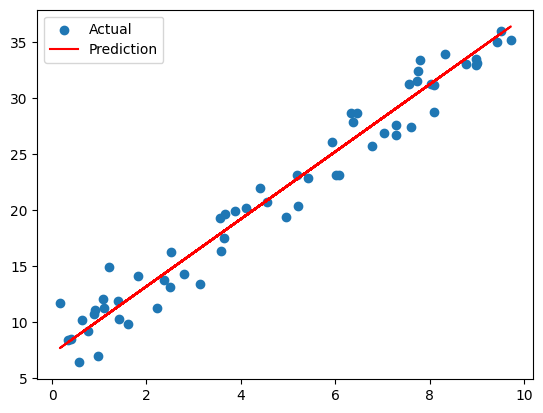

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split

# Generate simple linear data with noise
np.random.seed(42)
X = np.random.rand(200, 1) * 10
y = 3*X.squeeze() + 7 + np.random.randn(200)*2  # y = 3x + 7 + noise

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)

# Plot
plt.scatter(X_test, y_test, label='Actual')
plt.plot(X_test, y_pred, color='red', label='Prediction')
plt.legend()
plt.show()


## 1. Create Toy Dataset + Fit Linear Regression

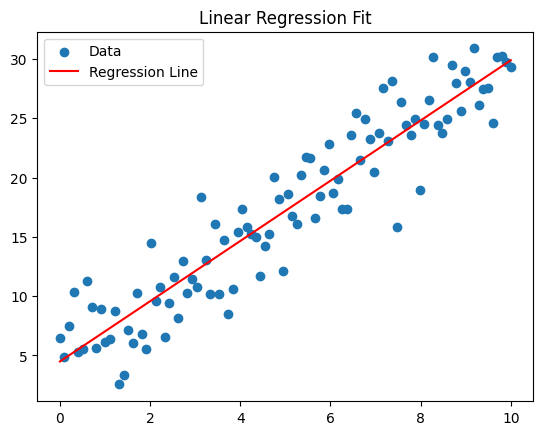

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

np.random.seed(42)

# Create dataset
X = np.linspace(0, 10, 100)
y = 2.5*X + 5 + np.random.normal(0, 3, 100)

df = pd.DataFrame({'X': X, 'y': y})

# Fit model
model = LinearRegression()
model.fit(df[['X']], df['y'])

df['pred'] = model.predict(df[['X']])
df['residual'] = df['y'] - df['pred']

plt.scatter(df['X'], df['y'], label="Data")
plt.plot(df['X'], df['pred'], color='red', label="Regression Line")
plt.legend()
plt.title("Linear Regression Fit")
plt.show()


# 2. Residual Plot (Check Linearity + Homoscedasticity)

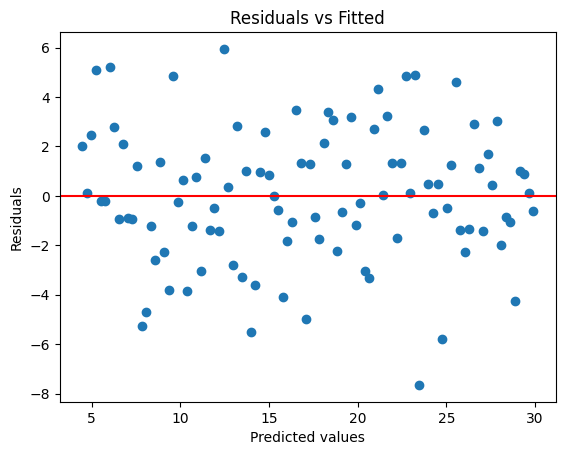

In [ ]:
plt.scatter(df['pred'], df['residual'])
plt.axhline(0, color='red')
plt.title("Residuals vs Fitted")
plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.show()


# 3. Scale-Location Plot (Check Constant Variance)

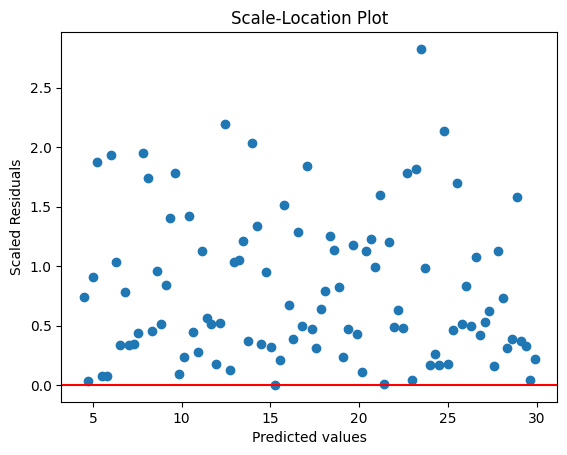

In [ ]:
import numpy as np

scaled_residuals = (np.abs(df['residual']) / np.sqrt(np.mean(df['residual']**2)))

plt.scatter(df['pred'], scaled_residuals)
plt.title("Scale-Location Plot")
plt.xlabel("Predicted values")
plt.ylabel("Scaled Residuals")
plt.axhline(0, color='red')
plt.show()


# 4. Normal Q-Q Plot (Check Residual Normality)

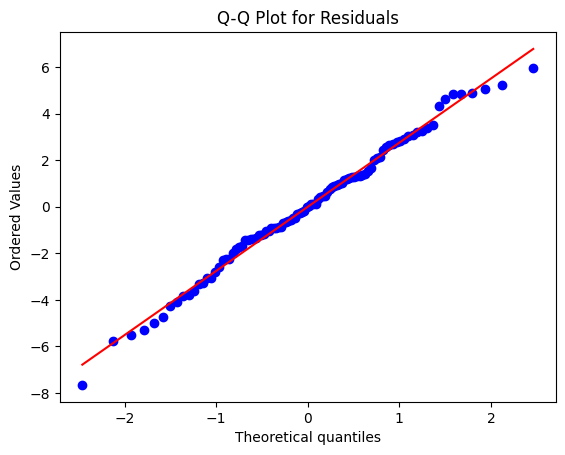

In [ ]:
import scipy.stats as stats
import matplotlib.pyplot as plt

stats.probplot(df['residual'], dist="norm", plot=plt)
plt.title("Q-Q Plot for Residuals")
plt.show()


# 5. Durbin-Watson Test (Autocorrelation)

In [ ]:
from statsmodels.stats.stattools import durbin_watson

dw = durbin_watson(df['residual'])
print("Durbin Watson:", dw)


Durbin Watson: 2.0424617053062484


Interpretation:

2 = No autocorrelation

<1 or >3 = serious autocorrelation

# 6. Detect Outliers Using Cook’s Distance

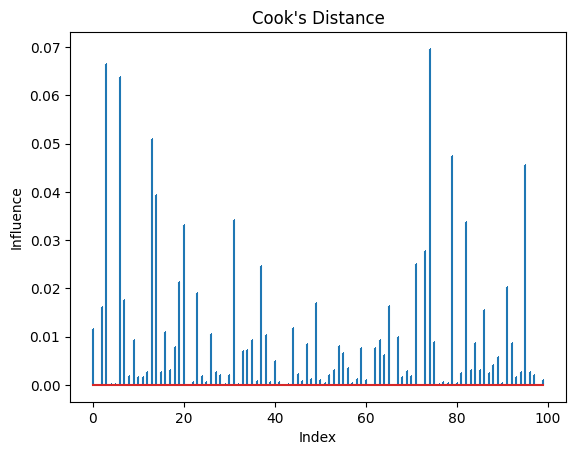

Points with Cook's Distance > 0.05:


(array([ 3,  6, 13, 74]),)

In [ ]:
import statsmodels.api as sm

X2 = sm.add_constant(df[['X']])
model_ols = sm.OLS(df['y'], X2).fit()
influence = model_ols.get_influence()
cooks = influence.cooks_distance[0]

plt.stem(np.arange(len(cooks)), cooks, markerfmt=",")
plt.title("Cook's Distance")
plt.xlabel("Index")
plt.ylabel("Influence")
plt.show()

print("Points with Cook's Distance > 0.05:")
np.where(cooks > 0.05)


# 7. Multicollinearity – VIF Score

In [ ]:
df['X2'] = df['X'] * 0.8 + np.random.normal(0, 1, 100)

from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = sm.add_constant(df[['X','X2']])
vif_data = pd.DataFrame()
vif_data['feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
print(vif_data)


  feature       VIF
0   const  3.940760
1       X  7.073769
2      X2  7.073769


Interpretation:

VIF > 5 → problematic

VIF > 10 → serious multicollinearity

# 8. Detect Non-linearity

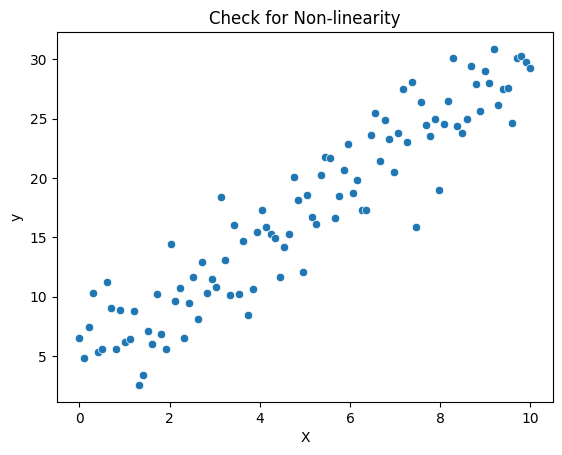

In [ ]:
sns.scatterplot(x=df['X'], y=df['y'])
plt.title("Check for Non-linearity")
plt.show()


**Alternative: Add polynomial feature and compare:**

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

poly = PolynomialFeatures(degree=2)
Xp = poly.fit_transform(df[['X']])

model_poly = LinearRegression().fit(Xp, df['y'])
pred_poly = model_poly.predict(Xp)

print("MSE Linear:", mean_squared_error(df['y'], df['pred']))
print("MSE Poly:", mean_squared_error(df['y'], pred_poly))


MSE Linear: 7.334142421482702
MSE Poly: 7.306188187924485


If polynomial MSE << linear MSE → data is non-linear.

# 9. Fix Issue: Log/Sqrt Transform Example (Heteroscedasticity)

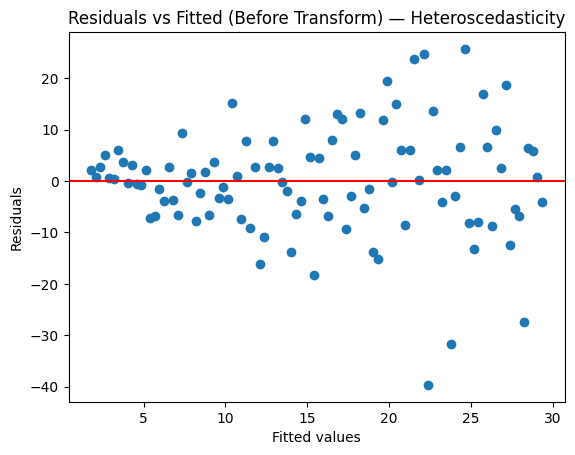

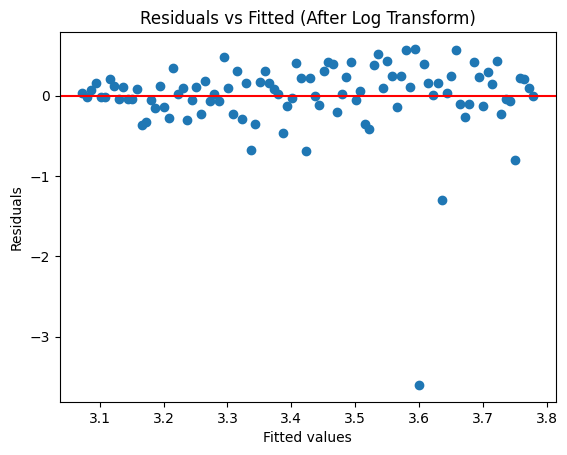

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

np.random.seed(42)

X = np.linspace(1, 10, 100)
y = 3*X + np.random.normal(0, X*2, 100)   # noise grows with X (heteroscedasticity)

df = pd.DataFrame({'X': X, 'y': y})

model = LinearRegression().fit(df[['X']], df['y'])
df['pred'] = model.predict(df[['X']])
df['residual'] = df['y'] - df['pred']

plt.scatter(df['pred'], df['residual'])
plt.axhline(0, color='red')
plt.title("Residuals vs Fitted (Before Transform) — Heteroscedasticity")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.show()

y_shifted = df['y'] - df['y'].min() + 1
df['y_log'] = np.log(y_shifted)

model_log = LinearRegression().fit(df[['X']], df['y_log'])
df['pred_log'] = model_log.predict(df[['X']])
df['residual_log'] = df['y_log'] - df['pred_log']

plt.scatter(df['pred_log'], df['residual_log'])
plt.axhline(0, color='red')
plt.title("Residuals vs Fitted (After Log Transform)")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.show()



# 10. Regularization (Ridge & Lasso)

In [ ]:
from sklearn.linear_model import Ridge, Lasso

ridge = Ridge(alpha=10).fit(df[['X','X2']], df['y'])
lasso = Lasso(alpha=0.1).fit(df[['X','X2']], df['y'])

print("Ridge Coefs:", ridge.coef_)
print("Lasso Coefs:", lasso.coef_)


Ridge Coefs: [ 2.62372354 -0.14115033]
Lasso Coefs: [ 2.68096509 -0.1889476 ]


# Time Series Models

## 1. ARIMA

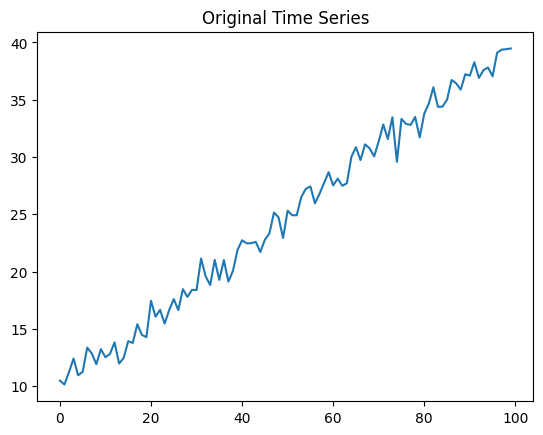

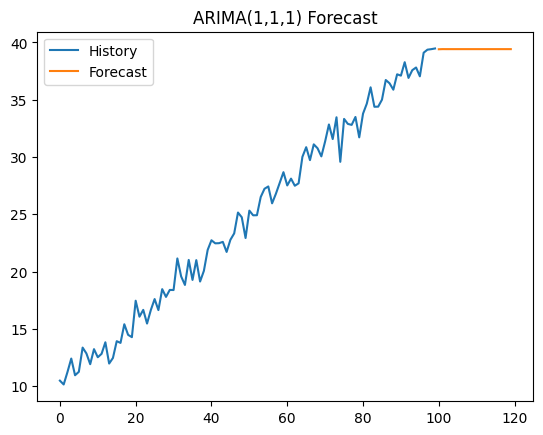

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# -----------------------------
# 1. Create simple synthetic time series
# -----------------------------
np.random.seed(42)
n = 100

time = np.arange(n)
trend = 0.3 * time                    # upward trend
noise = np.random.normal(0, 1, n)
series = 10 + trend + noise

df = pd.Series(series)

plt.plot(df)
plt.title("Original Time Series")
plt.show()

# -----------------------------
# 2. Fit ARIMA(p,d,q) model
# -----------------------------
# Let's use ARIMA(1,1,1) — simple and commonly used
model = ARIMA(df, order=(1,1,1))
model_fit = model.fit()

# -----------------------------
# 3. Forecast next 20 points
# -----------------------------
forecast_steps = 20
forecast = model_fit.forecast(steps=forecast_steps)

# Create index for forecast range
forecast_index = np.arange(len(df), len(df) + forecast_steps)

# -----------------------------
# 4. Plot historical + forecast
# -----------------------------
plt.plot(df, label="History")
plt.plot(forecast_index, forecast, label="Forecast")
plt.title("ARIMA(1,1,1) Forecast")
plt.legend()
plt.show()


## 2. SARIMA

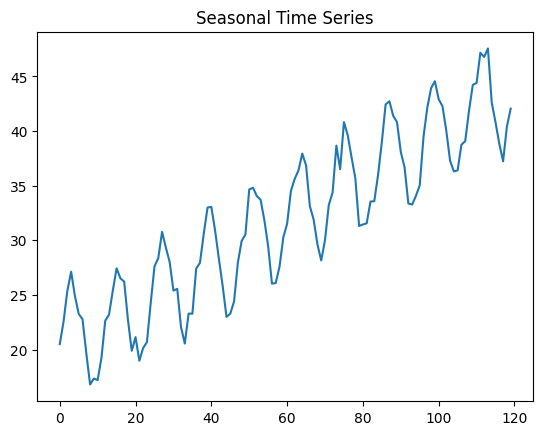

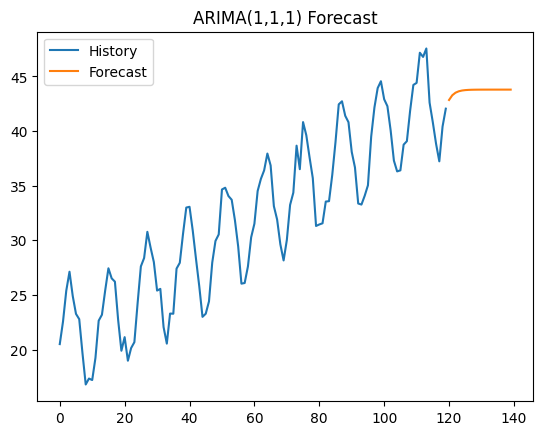

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# -----------------------------
# 1. Create simple synthetic time series
# -----------------------------
np.random.seed(42)
n = 120   # 10 years of monthly data (12*10)

time = np.arange(n)

trend = 0.2 * time
seasonality = 5 * np.sin(2 * np.pi * time / 12)   # yearly seasonality
noise = np.random.normal(0, 1, n)

series = 20 + trend + seasonality + noise
df = pd.Series(series)

plt.plot(df)
plt.title("Seasonal Time Series")
plt.show()

# -----------------------------
# 2. Fit ARIMA(p,d,q) model
# -----------------------------
# Let's use ARIMA(1,1,1) — simple and commonly used
model = ARIMA(df, order=(1,1,1))
model_fit = model.fit()

# -----------------------------
# 3. Forecast next 20 points
# -----------------------------
forecast_steps = 20
forecast = model_fit.forecast(steps=forecast_steps)

# Create index for forecast range
forecast_index = np.arange(len(df), len(df) + forecast_steps)

# -----------------------------
# 4. Plot historical + forecast
# -----------------------------
plt.plot(df, label="History")
plt.plot(forecast_index, forecast, label="Forecast")
plt.title("ARIMA(1,1,1) Forecast")
plt.legend()
plt.show()


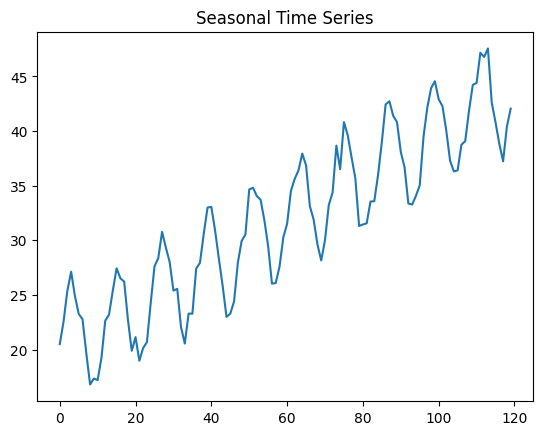

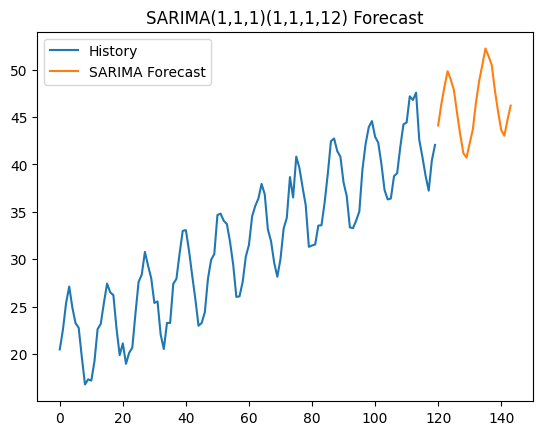

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# -----------------------------
# 1. Create simple seasonal time series
# -----------------------------
np.random.seed(42)
n = 120   # 10 years of monthly data (12*10)

time = np.arange(n)

trend = 0.2 * time
seasonality = 5 * np.sin(2 * np.pi * time / 12)   # yearly seasonality
noise = np.random.normal(0, 1, n)

series = 20 + trend + seasonality + noise
df = pd.Series(series)

plt.plot(df)
plt.title("Seasonal Time Series")
plt.show()

# -----------------------------
# 2. Fit SARIMA(p,d,q)(P,D,Q,12) model
# -----------------------------
# Let's use SARIMA(1,1,1)(1,1,1,12)
model = SARIMAX(df,
                order=(1,1,1),
                seasonal_order=(1,1,1,12))
model_fit = model.fit()

# -----------------------------
# 3. Forecast next 24 months
# -----------------------------
forecast_steps = 24
forecast = model_fit.forecast(steps=forecast_steps)

forecast_index = np.arange(len(df), len(df) + forecast_steps)

# -----------------------------
# 4. Plot historical + forecast
# -----------------------------
plt.plot(df, label="History")
plt.plot(forecast_index, forecast, label="SARIMA Forecast")
plt.title("SARIMA(1,1,1)(1,1,1,12) Forecast")
plt.legend()
plt.show()


# Classification Models

## 1. Logistic Regression

Step-1: Import libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, roc_auc_score, precision_recall_curve
)


Step-2: Create synthetic dataset (clean, linearly separable)

In [ ]:
np.random.seed(42)

n = 500
x1 = np.random.normal(3, 1.2, n)
x2 = np.random.normal(2, 1.0, n)

# True decision boundary: x1 + x2 > 5
y = (x1 + x2 > 5).astype(int)

df = pd.DataFrame({'x1': x1, 'x2': x2, 'y': y})
df.head()


,x1,x2,y
0,3.596057,2.926178,1
1,2.834083,3.909417,1
2,3.777226,0.601432,0
3,4.827636,2.562969,1
4,2.719016,1.349357,0


Step-3: Visualize dataset

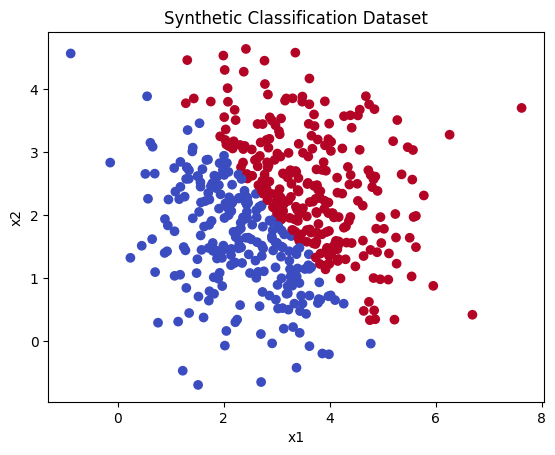

In [ ]:
plt.scatter(df['x1'], df['x2'], c=df['y'], cmap='coolwarm')
plt.title("Synthetic Classification Dataset")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()


Step-4: Train–Test Split

In [ ]:
X = df[['x1','x2']]
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)


Step-5: Fit Logistic Regression

In [ ]:
model = LogisticRegression()
model.fit(X_train, y_train)


LogisticRegression()

Step-6: Predict probabilities + Apply threshold

In [ ]:
proba = model.predict_proba(X_test)[:, 1]   # P(y=1|x)
y_pred_05 = (proba >= 0.5).astype(int)


Step-7: Evaluate Performance

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_05))
print("Precision:", precision_score(y_test, y_pred_05))
print("Recall:", recall_score(y_test, y_pred_05))
print("F1-Score:", f1_score(y_test, y_pred_05))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_05))


Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-Score: 1.0

Confusion Matrix:
[[61  0]
 [ 0 64]]


Step-8: ROC Curve + AUC (Model Selection Metric)

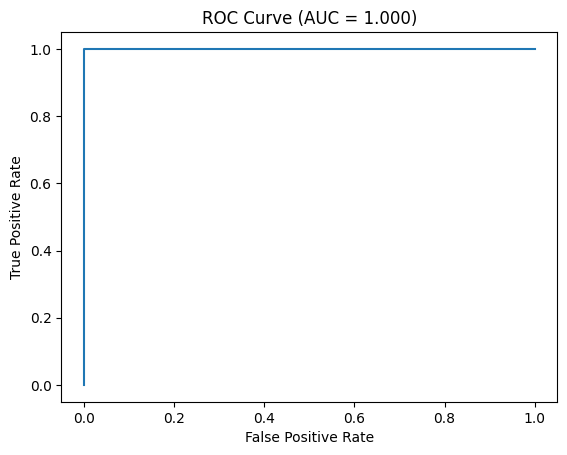

In [ ]:
fpr, tpr, _ = roc_curve(y_test, proba)
auc = roc_auc_score(y_test, proba)

plt.plot(fpr, tpr)
plt.title(f"ROC Curve (AUC = {auc:.3f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()


Step-9: Precision–Recall Curve (useful for imbalance)

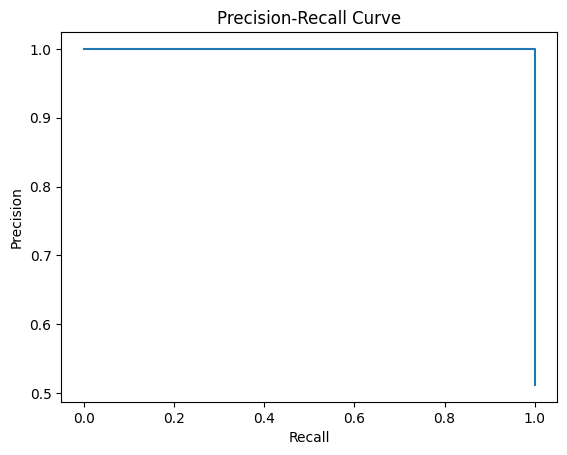

In [ ]:
precision, recall, _ = precision_recall_curve(y_test, proba)

plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()


Step-10:Threshold Tuning Example

In [ ]:
threshold = 0.3
y_pred_03 = (proba >= threshold).astype(int)

print("Threshold = 0.3")
print("Precision:", precision_score(y_test, y_pred_03))
print("Recall:", recall_score(y_test, y_pred_03))


Threshold = 0.3
Precision: 0.9142857142857143
Recall: 1.0


➡ Shows business alignment:

Lower threshold → higher recall (good when FN costly)

Higher threshold → higher precision

Step-11: Coefficient Interpretation (β → odds ratio)

In [ ]:
coef = model.coef_[0]
intercept = model.intercept_[0]

print("Coefficients:", coef)
print("Intercept:", intercept)

odds_ratio = np.exp(coef)
print("Odds Ratios:", odds_ratio)


Coefficients: [4.45064075 4.225269  ]
Intercept: -21.620108279169585
Odds Ratios: [85.68182743 68.39289886]


➡ Shows how each feature affects log-odds.

Step-12: Demonstrate Regularization (L1 vs L2)

In [ ]:
model_l1 = LogisticRegression(penalty='l1', solver='liblinear')
model_l1.fit(X_train, y_train)

model_l2 = LogisticRegression(penalty='l2')
model_l2.fit(X_train, y_train)

print("L1 Coefficients:", model_l1.coef_)
print("L2 Coefficients:", model_l2.coef_)


L1 Coefficients: [[4.94568017 4.76217736]]
L2 Coefficients: [[4.45064075 4.225269  ]]


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Step-13: Impact of Imbalanced Data

In [ ]:
df_imb = df.copy()
df_imb['y'] = df['y'].replace({1:1, 0:0})

# Make 95% zeros
mask = df_imb['y'] == 1
df_imb = pd.concat([df_imb[mask], df_imb[~mask].sample(50)], ignore_index=True)

df_imb['y'].value_counts()

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    df_imb[['x1','x2']], df_imb['y'], test_size=0.25, random_state=42
)

imb_model = LogisticRegression()
imb_model.fit(X_train2, y_train2)

pred = imb_model.predict(X_test2)

print("Accuracy:", accuracy_score(y_test2, pred))
print("Precision:", precision_score(y_test2, pred))
print("Recall:", recall_score(y_test2, pred))


Accuracy: 0.9615384615384616
Precision: 0.9577464788732394
Recall: 1.0


Step-14: Fixing imbalance using class_weight='balanced'

In [ ]:
balanced_model = LogisticRegression(class_weight='balanced')
balanced_model.fit(X_train2, y_train2)

balanced_pred = balanced_model.predict(X_test2)

print("Balanced Accuracy:", accuracy_score(y_test2, balanced_pred))
print("Balanced Precision:", precision_score(y_test2, balanced_pred))
print("Balanced Recall:", recall_score(y_test2, balanced_pred))


Balanced Accuracy: 0.9871794871794872
Balanced Precision: 0.9855072463768116
Balanced Recall: 1.0


## 2. Naive Bayes

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
np.random.seed(42)

# Class 0
x1_0 = np.random.normal(1, 1, 200)
x2_0 = np.random.normal(1, 1, 200)

# Class 1
x1_1 = np.random.normal(4, 1, 200)
x2_1 = np.random.normal(4, 1, 200)

# Combine
X = np.vstack([
    np.column_stack([x1_0, x2_0]),
    np.column_stack([x1_1, x2_1])
])

y = np.array([0]*200 + [1]*200)

df = pd.DataFrame({'x1': X[:,0], 'x2': X[:,1], 'y': y})
df.head()


,x1,x2,y
0,1.496714,1.357787,0
1,0.861736,1.560785,0
2,1.647689,2.083051,0
3,2.523030,2.053802,0
4,0.765847,-0.377669,0


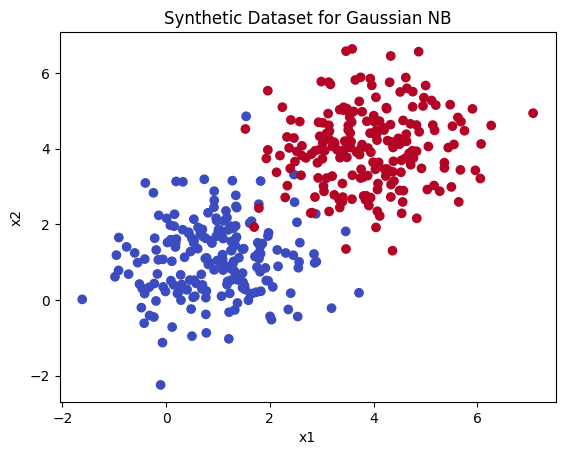

In [ ]:
plt.scatter(df['x1'], df['x2'], c=df['y'], cmap='coolwarm')
plt.title("Synthetic Dataset for Gaussian NB")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df[['x1','x2']], df['y'], test_size=0.25, random_state=42
)
gnb = GaussianNB()
gnb.fit(X_train, y_train)
pred = gnb.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, pred))
print("\nClassification Report:\n", classification_report(y_test, pred))


Accuracy: 0.95

Confusion Matrix:
 [[49  3]
 [ 2 46]]

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.94      0.95        52
           1       0.94      0.96      0.95        48

    accuracy                           0.95       100
   macro avg       0.95      0.95      0.95       100
weighted avg       0.95      0.95      0.95       100



In [ ]:
test_point = X_test.values[0].reshape(1, -1)
p = gnb.predict_proba(test_point)
print("P(y=0|x), P(y=1|x) =", p)
print("Predicted class =", np.argmax(p))


P(y=0|x), P(y=1|x) = [[9.12562871e-08 9.99999909e-01]]
Predicted class = 1


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


Demonstrate Zero-Probability Problem

In [ ]:
from sklearn.naive_bayes import BernoulliNB

X_bin = np.array([
    [1,0,1],
    [1,1,0],
    [0,1,1],
])

y_bin = np.array([0,0,1])

bnb = BernoulliNB(alpha=0)
bnb.fit(X_bin, y_bin)

print("Pred probabilities:", bnb.predict_proba(X_bin))


Pred probabilities: [[nan nan]
 [nan nan]
 [nan nan]]


/usr/local/lib/python3.12/dist-packages/sklearn/naive_bayes.py:1209: RuntimeWarning: divide by zero encountered in log
  self.feature_log_prob_ = np.log(smoothed_fc) - np.log(
/usr/local/lib/python3.12/dist-packages/sklearn/naive_bayes.py:1224: RuntimeWarning: divide by zero encountered in log
  neg_prob = np.log(1 - np.exp(self.feature_log_prob_))
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/usr/local/lib/python3.12/dist-packages/sklearn/naive_bayes.py:1227: RuntimeWarning: invalid value encountered in add
  jll += self.class_log_prior_ + neg_prob.sum(axis=1)


Fix Zero-Probability Using Laplace Smoothing (α > 0)

In [ ]:
bnb_smoothed = BernoulliNB(alpha=1)
bnb_smoothed.fit(X_bin, y_bin)
print("With smoothing:", bnb_smoothed.predict_proba(X_bin))


With smoothing: [[0.83505155 0.16494845]
 [0.83505155 0.16494845]
 [0.2967033  0.7032967 ]]


Show NB struggling with Correlated Features

In [ ]:
x = np.random.normal(0,1,300)
X_corr = np.column_stack([x, x + np.random.normal(0,0.2,300)])
y_corr = (x > 0).astype(int)

gnb2 = GaussianNB()
gnb2.fit(X_corr, y_corr)
pred_corr = gnb2.predict(X_corr)

print("Accuracy with correlated features:", accuracy_score(y_corr, pred_corr))


Accuracy with correlated features: 0.97


NB will often become overconfident, sometimes even with 100% prediction but wrong boundaries.

Text Classification Example (Multinomial NB)

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

texts = ["spam offer win money",
         "win cash now",
         "hello friend how are you",
         "meeting at office tomorrow"]

y_text = [1, 1, 0, 0]  # 1 = spam

cv = CountVectorizer()
X_text = cv.fit_transform(texts)

mnb = MultinomialNB()
mnb.fit(X_text, y_text)

print("Predictions:", mnb.predict(X_text))
print("Probabilities:\n", mnb.predict_proba(X_text))


Predictions: [1 1 0 0]
Probabilities:
 [[0.02857868 0.97142132]
 [0.06031631 0.93968369]
 [0.95394102 0.04605898]
 [0.9186798  0.0813202 ]]


## 3. SVM

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

np.random.seed(42)

# Class 0
x1_0 = np.random.normal(1, 1, 150)
x2_0 = np.random.normal(1, 1, 150)

# Class 1
x1_1 = np.random.normal(4, 1, 150)
x2_1 = np.random.normal(4, 1, 150)

X = np.vstack([
    np.column_stack([x1_0, x2_0]),
    np.column_stack([x1_1, x2_1])
])

y = np.array([0]*150 + [1]*150)


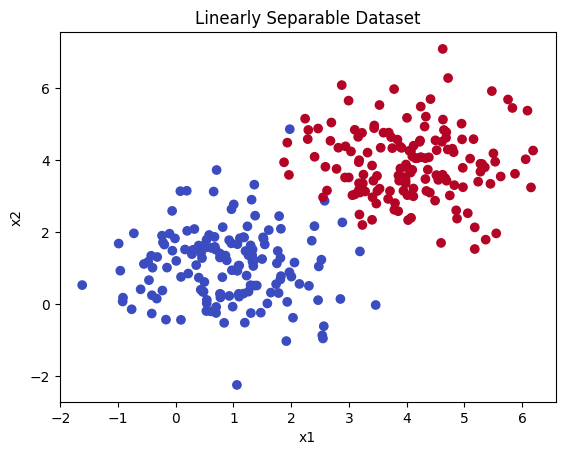

In [ ]:
plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm')
plt.title("Linearly Separable Dataset")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()


Scaling Mandatory

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train_scaled, y_train)
pred = svm_linear.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, pred))
print("Number of support vectors:", svm_linear.n_support_)



Accuracy: 0.9733333333333334
Number of support vectors: [7 6]


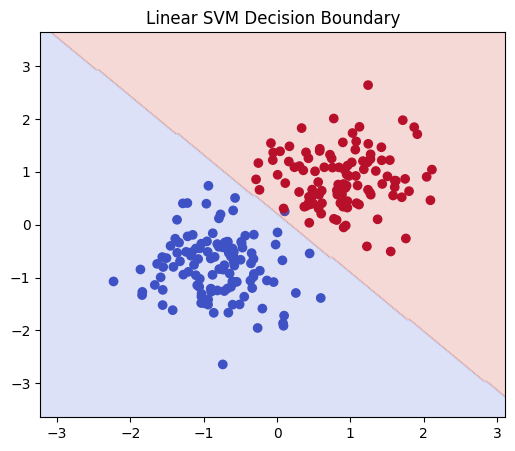

In [ ]:
def plot_decision_boundary(model, X, y, title):
    plt.figure(figsize=(6,5))

    # Plot points
    plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm')

    # Grid for contour
    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.2, cmap='coolwarm')
    plt.title(title)
    plt.show()

plot_decision_boundary(svm_linear, X_train_scaled, y_train, "Linear SVM Decision Boundary")


Low C accuracy: 0.9733333333333334
High C accuracy: 0.9866666666666667


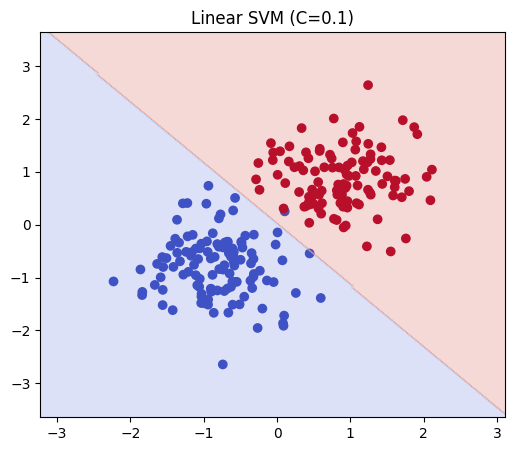

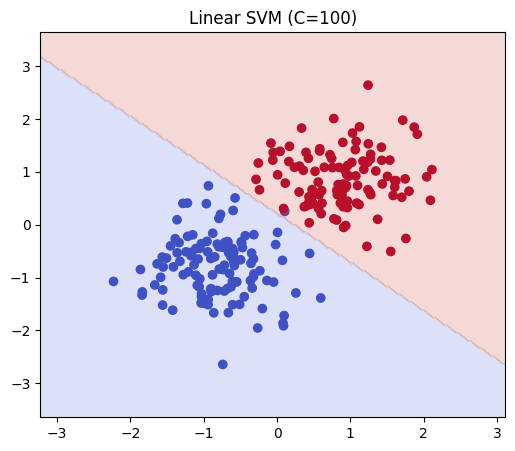

In [ ]:
svm_lowC = SVC(kernel='linear', C=0.1)
svm_highC = SVC(kernel='linear', C=100)

svm_lowC.fit(X_train_scaled, y_train)
svm_highC.fit(X_train_scaled, y_train)

print("Low C accuracy:", accuracy_score(y_test, svm_lowC.predict(X_test_scaled)))
print("High C accuracy:", accuracy_score(y_test, svm_highC.predict(X_test_scaled)))

plot_decision_boundary(svm_lowC, X_train_scaled, y_train, "Linear SVM (C=0.1)")
plot_decision_boundary(svm_highC, X_train_scaled, y_train, "Linear SVM (C=100)")


🔹 Low C → wide margin, more misclassifications

🔹 High C → narrow margin, tries to classify perfectly

Now Create Non-Linear Data (to use RBF kernel)

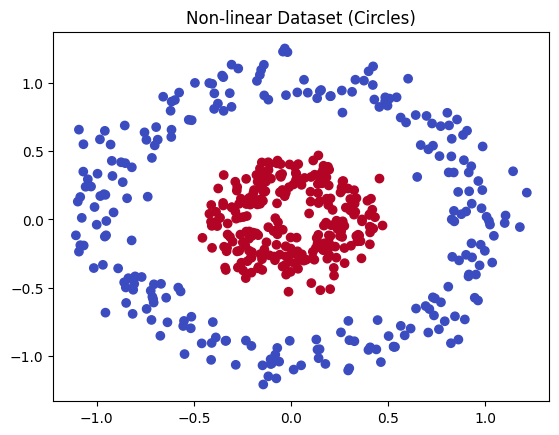

In [ ]:
from sklearn.datasets import make_circles

X_nl, y_nl = make_circles(n_samples=500, noise=0.1, factor=0.3)

plt.scatter(X_nl[:,0], X_nl[:,1], c=y_nl, cmap='coolwarm')
plt.title("Non-linear Dataset (Circles)")
plt.show()


Accuracy (RBF): 1.0


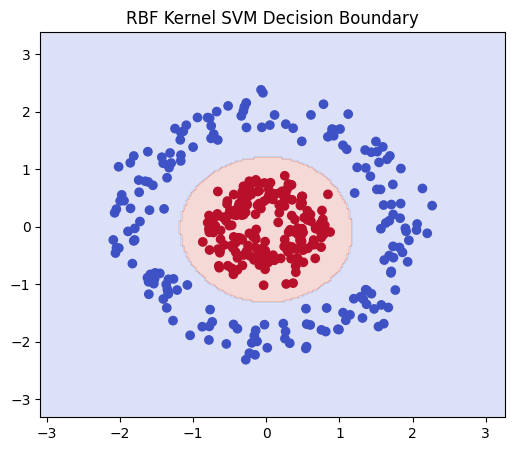

In [ ]:
X_train_nl, X_test_nl, y_train_nl, y_test_nl = train_test_split(X_nl, y_nl, test_size=0.25)

scaler2 = StandardScaler()
X_train_nl = scaler2.fit_transform(X_train_nl)
X_test_nl = scaler2.transform(X_test_nl)

svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(X_train_nl, y_train_nl)

print("Accuracy (RBF):", accuracy_score(y_test_nl, svm_rbf.predict(X_test_nl)))
plot_decision_boundary(svm_rbf, X_train_nl, y_train_nl, "RBF Kernel SVM Decision Boundary")


✔ Shows Kernel Trick → Non-linear boundary!

✔ SVM can separate circles with RBF.

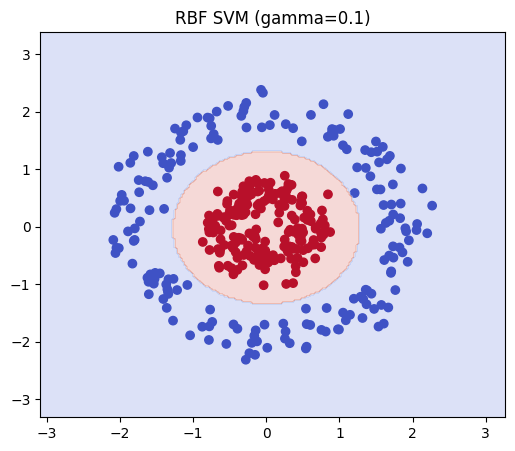

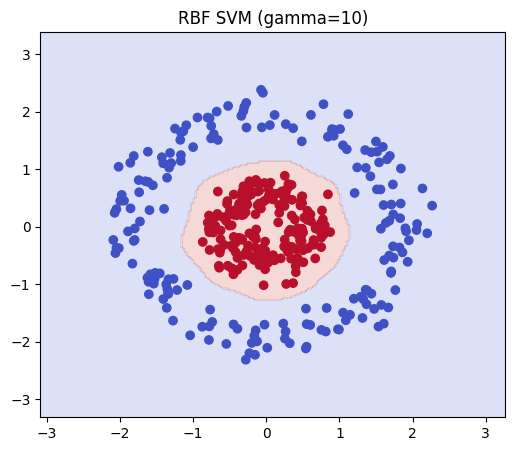

In [ ]:
svm_gamma_low = SVC(kernel='rbf', gamma=0.1)
svm_gamma_high = SVC(kernel='rbf', gamma=10)

svm_gamma_low.fit(X_train_nl, y_train_nl)
svm_gamma_high.fit(X_train_nl, y_train_nl)

plot_decision_boundary(svm_gamma_low, X_train_nl, y_train_nl, "RBF SVM (gamma=0.1)")
plot_decision_boundary(svm_gamma_high, X_train_nl, y_train_nl, "RBF SVM (gamma=10)")



🔹Low gamma → smooth boundary

🔹 High gamma → highly curved boundary → overfit

In [ ]:
print("Number of support vectors per class:", svm_rbf.n_support_)
print("Total support vectors:", svm_rbf.support_.shape[0])


Number of support vectors per class: [14 12]
Total support vectors: 26


## 4. Decision Trees

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error

np.random.seed(42)

# Class 0
x1_0 = np.random.normal(1, 1, 150)
x2_0 = np.random.normal(1, 1, 150)

# Class 1
x1_1 = np.random.normal(4, 1, 150)
x2_1 = np.random.normal(4, 1, 150)

X = np.vstack([
    np.column_stack([x1_0, x2_0]),
    np.column_stack([x1_1, x2_1])
])

y = np.array([0]*150 + [1]*150)


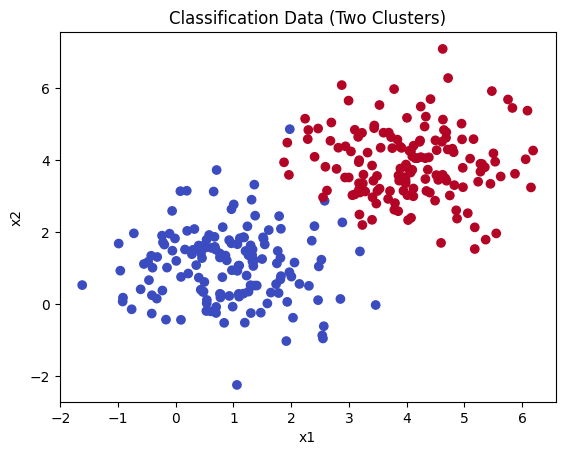

In [ ]:
plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm')
plt.title("Classification Data (Two Clusters)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)
tree_gini = DecisionTreeClassifier(criterion='gini')
tree_gini.fit(X_train, y_train)
pred = tree_gini.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred))


Accuracy: 0.92


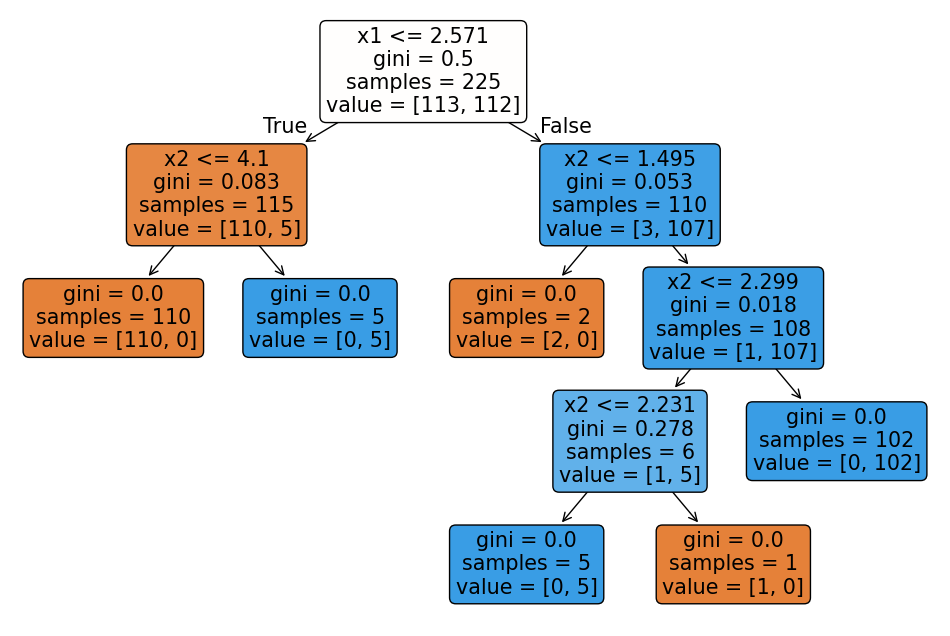

In [ ]:
plt.figure(figsize=(12,8))
plot_tree(tree_gini, feature_names=['x1','x2'], filled=True, rounded=True)
plt.show()


Switching to entropy (Information Gain)

In [ ]:
tree_entropy = DecisionTreeClassifier(criterion='entropy')
tree_entropy.fit(X_train, y_train)

pred_entropy = tree_entropy.predict(X_test)
print("Entropy Accuracy:", accuracy_score(y_test, pred_entropy))


Entropy Accuracy: 0.9066666666666666


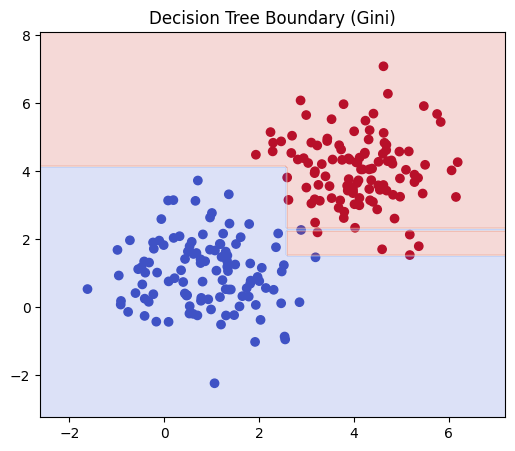

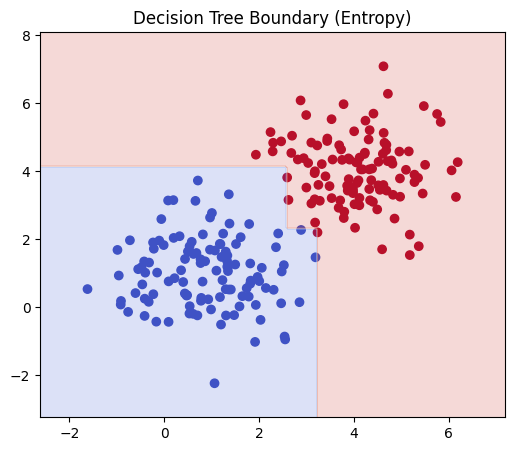

In [ ]:
def plot_boundary(model, X, y, title):
    plt.figure(figsize=(6,5))
    plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm')

    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1
    xx, yy = np.meshgrid(np.linspace(x_min,x_max,200),
                         np.linspace(y_min,y_max,200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.2, cmap='coolwarm')
    plt.title(title)
    plt.show()

plot_boundary(tree_gini, X_train, y_train, "Decision Tree Boundary (Gini)")
plot_boundary(tree_entropy, X_train, y_train, "Decision Tree Boundary (Entropy)")


Demonstrate Overfitting (Deep Tree)

In [ ]:
deep_tree = DecisionTreeClassifier(max_depth=None)
deep_tree.fit(X_train, y_train)

train_acc = accuracy_score(y_train, deep_tree.predict(X_train))
test_acc = accuracy_score(y_test, deep_tree.predict(X_test))

print("Train Accuracy (Deep Tree):", train_acc)
print("Test Accuracy (Deep Tree):", test_acc)


Train Accuracy (Deep Tree): 1.0
Test Accuracy (Deep Tree): 0.92


Fix Overfitting Using Regularization

Limit depth

In [ ]:
pruned_tree = DecisionTreeClassifier(max_depth=3)
pruned_tree.fit(X_train, y_train)

print("Accuracy (max_depth=3):", accuracy_score(y_test, pruned_tree.predict(X_test)))


Accuracy (max_depth=3): 0.92


Increase min samples per leaf

In [ ]:
tree_min_leaf = DecisionTreeClassifier(min_samples_leaf=10)
tree_min_leaf.fit(X_train, y_train)

print("Accuracy (min_samples_leaf=10):", accuracy_score(y_test, tree_min_leaf.predict(X_test)))


Accuracy (min_samples_leaf=10): 0.92


In [ ]:
print("Feature Importances:", tree_gini.feature_importances_)


Feature Importances: [0.86309435 0.13690565]


Build a Regression Tree

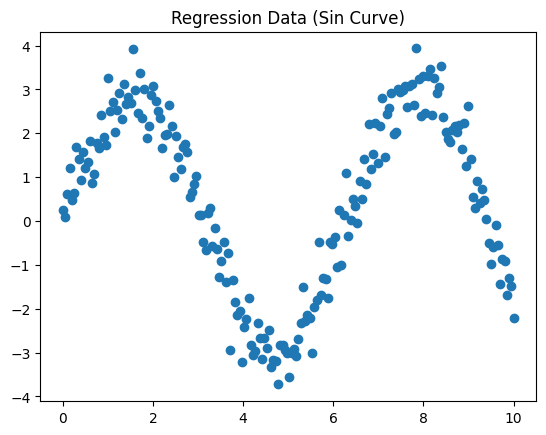

In [ ]:
np.random.seed(42)
Xr = np.linspace(0, 10, 200).reshape(-1,1)
yr = 3 * np.sin(Xr).ravel() + np.random.normal(0, 0.5, 200)

plt.scatter(Xr, yr)
plt.title("Regression Data (Sin Curve)")
plt.show()


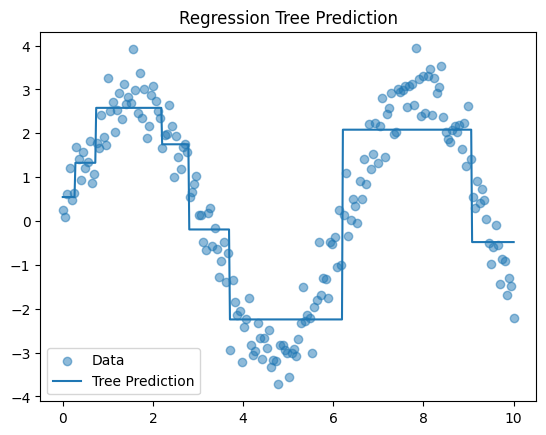

MSE: 0.6741442972151822


In [ ]:
reg_tree = DecisionTreeRegressor(max_depth=3)
reg_tree.fit(Xr, yr)
x_plot = np.linspace(0,10,500).reshape(-1,1)
y_pred_r = reg_tree.predict(x_plot)

plt.scatter(Xr, yr, alpha=0.5, label="Data")
plt.plot(x_plot, y_pred_r, label="Tree Prediction")
plt.title("Regression Tree Prediction")
plt.legend()
plt.show()

mse = mean_squared_error(yr, reg_tree.predict(Xr))
print("MSE:", mse)


## 5. Random Forest

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

np.random.seed(42)

# Class 0
x1_0 = np.random.normal(1, 1, 150)
x2_0 = np.random.normal(1, 1, 150)

# Class 1
x1_1 = np.random.normal(4, 1, 150)
x2_1 = np.random.normal(4, 1, 150)

X = np.vstack([
    np.column_stack([x1_0, x2_0]),
    np.column_stack([x1_1, x2_1])
])

y = np.array([0]*150 + [1]*150)


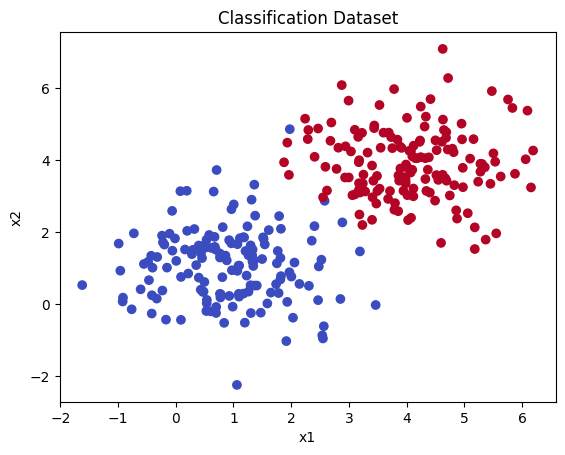

In [ ]:
plt.scatter(X[:,0], X[:,1], c=y, cmap="coolwarm")
plt.title("Classification Dataset")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)


**Train a Single Deep Decision Tree (to show overfitting)**

In [ ]:
tree = DecisionTreeClassifier(max_depth=None)
tree.fit(X_train, y_train)

train_acc = accuracy_score(y_train, tree.predict(X_train))
test_acc  = accuracy_score(y_test, tree.predict(X_test))

print("Single Tree Train Accuracy:", train_acc)
print("Single Tree Test Accuracy :", test_acc)


Single Tree Train Accuracy: 1.0
Single Tree Test Accuracy : 0.92


**Train Random Forest (basic)**

In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,       # 200 trees
    max_features="sqrt",   # random subset of features per split
    random_state=42
)
rf.fit(X_train, y_train)

train_acc = accuracy_score(y_train, rf.predict(X_train))
test_acc  = accuracy_score(y_test, rf.predict(X_test))

print("Random Forest Train Accuracy:", train_acc)
print("Random Forest Test Accuracy :", test_acc)


Random Forest Train Accuracy: 1.0
Random Forest Test Accuracy : 0.9733333333333334


**Compare Decision Boundary (Tree vs Forest)**

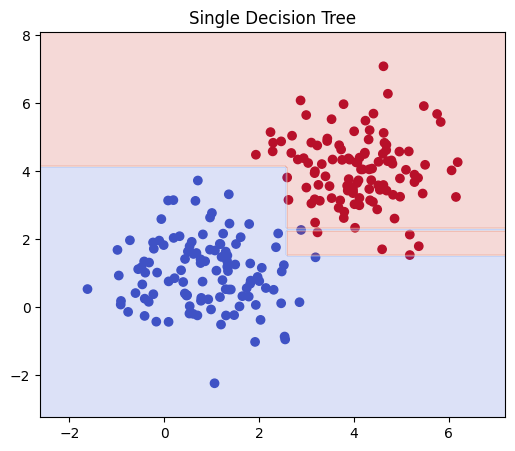

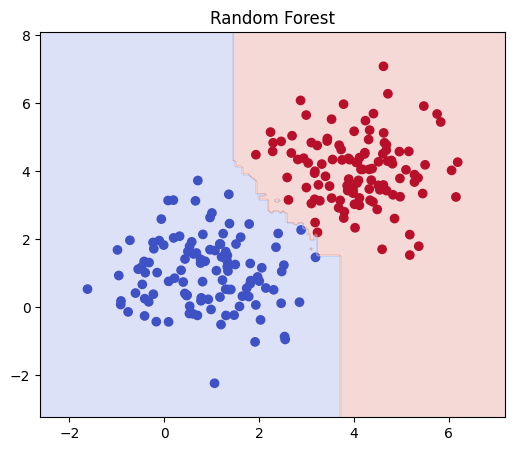

In [ ]:
def plot_boundary(model, X, y, title):
    plt.figure(figsize=(6,5))
    plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm')

    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1
    xx, yy = np.meshgrid(np.linspace(x_min,x_max,200),
                         np.linspace(y_min,y_max,200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.2, cmap='coolwarm')
    plt.title(title)
    plt.show()

plot_boundary(tree, X_train, y_train, "Single Decision Tree")
plot_boundary(rf, X_train, y_train, "Random Forest")


You will visually see:

Single tree = sharp, jagged, overfit boundaries

Random Forest = smoother, generalized boundaries

This is the core intuition behind Random Forests.

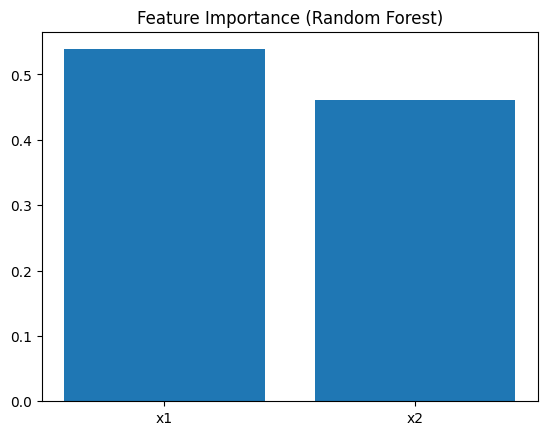

In [ ]:
rf.feature_importances_
plt.bar(['x1','x2'], rf.feature_importances_)
plt.title("Feature Importance (Random Forest)")
plt.show()


✔ Shows which feature is more useful for splits

✔ Forest averages importance across all trees

**Out-of-Bag (OOB) Score — Internal Validation**

In [ ]:
rf_oob = RandomForestClassifier(
    n_estimators=300,
    oob_score=True,
    bootstrap=True,
    random_state=42
)
rf_oob.fit(X_train, y_train)

print("OOB Score:", rf_oob.oob_score_)


OOB Score: 0.9911111111111112


OOB Score Meaning:

Each tree trains on a bootstrap sample (sample with replacement)

~37% of samples are "Out-of-Bag"

Those unused samples act like a built-in validation set

✔ No need for separate validation

✔ Good indicator of model performance

✔ OOB score = internal validation accuracy

✔ Calculated using samples NOT seen by each tree

✔ Similar to k-fold CV accuracy

✔ Good for hyperparameter tuning

✔ Saves time (no separate validation set needed)


**Effect of Number of Trees (n_estimators)**

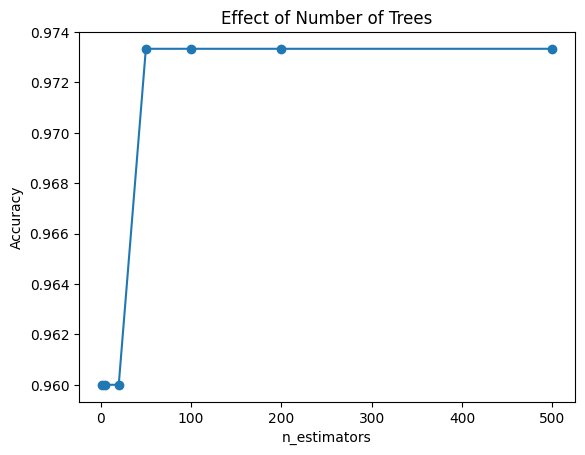

In [ ]:
trees = [1, 5, 20, 50, 100, 200, 500]
accuracies = []

for t in trees:
    rf_t = RandomForestClassifier(n_estimators=t, random_state=42)
    rf_t.fit(X_train, y_train)
    acc = accuracy_score(y_test, rf_t.predict(X_test))
    accuracies.append(acc)

plt.plot(trees, accuracies, marker='o')
plt.title("Effect of Number of Trees")
plt.xlabel("n_estimators")
plt.ylabel("Accuracy")
plt.show()


✔ Performance improves rapidly at first

✔ After ~100 trees, benefits become small

✔ Random Forests don’t overfit with more trees

**Effect of max_features (key RF hyperparameter)**

In [ ]:
settings = ["sqrt", "log2", None]
results = []

for setting in settings:
    rf_mf = RandomForestClassifier(max_features=setting, n_estimators=200)
    rf_mf.fit(X_train, y_train)
    result = accuracy_score(y_test, rf_mf.predict(X_test))
    results.append(result)

for setting, r in zip(settings, results):
    print(setting, ":", r)


sqrt : 0.9733333333333334
log2 : 0.9733333333333334
None : 0.9333333333333333


Meaning:

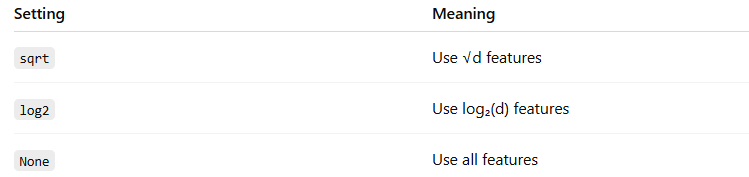

"sqrt" → very common for classification

"log2" → more randomness

None → consider ALL features (behaves more like bagged trees)-> But this reduces randomness → trees become similar → Random Forest loses its advantage → more overfitting.

If overfitting → try "log2" or smaller fractions

If underfitting → increase max_features



## 6. AdaBoost

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

np.random.seed(42)

# Class 0
x1_0 = np.random.normal(1, 1, 150)
x2_0 = np.random.normal(1, 1, 150)

# Class 1
x1_1 = np.random.normal(4, 1, 150)
x2_1 = np.random.normal(4, 1, 150)

X = np.vstack([np.column_stack([x1_0, x2_0]),
               np.column_stack([x1_1, x2_1])])
y = np.array([0]*150 + [1]*150)


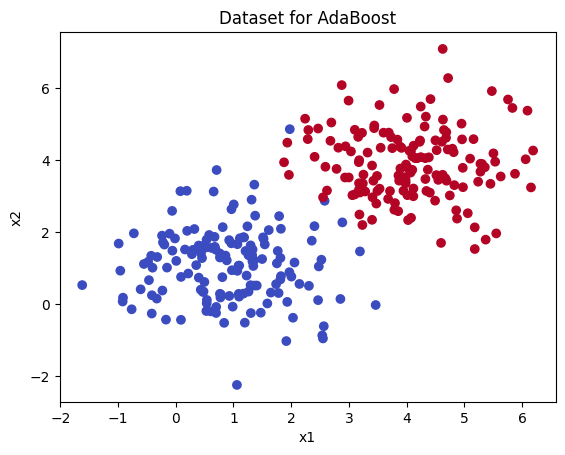

In [ ]:
plt.scatter(X[:,0], X[:,1], c=y, cmap="coolwarm")
plt.title("Dataset for AdaBoost")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)


**Train a Weak Learner: Decision Stump**

Decision stump = tree with max_depth=1

In [ ]:
stump = DecisionTreeClassifier(max_depth=1)
stump.fit(X_train, y_train)

pred_stump = stump.predict(X_test)
print("Stump Accuracy:", accuracy_score(y_test, pred_stump))


Stump Accuracy: 0.92


✔ Accuracy will be low → intentionally weak

✔ This is the base learner AdaBoost improves

**Train AdaBoost**

In [ ]:
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    learning_rate=1.0
)
ada.fit(X_train, y_train)

pred_ada = ada.predict(X_test)
print("AdaBoost Accuracy:", accuracy_score(y_test, pred_ada))


AdaBoost Accuracy: 0.9466666666666667


✔ Should be MUCH higher than stump

✔ Boosting reduces bias dramatically

**Decision boundary visualization**

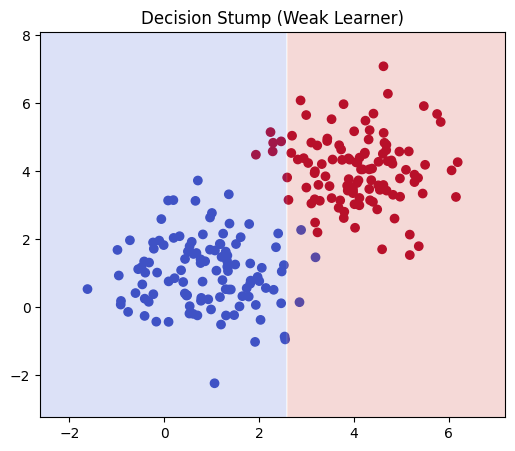

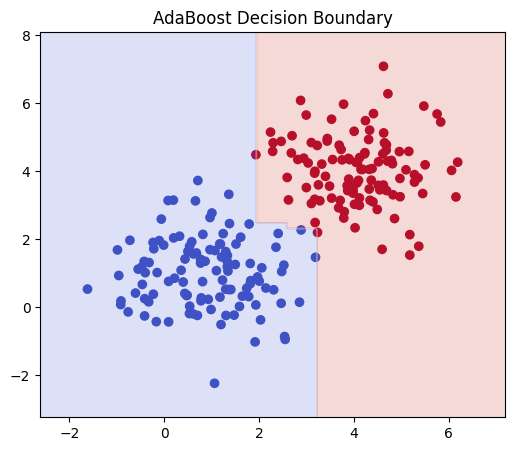

In [ ]:
def plot_boundary(model, X, y, title):
    plt.figure(figsize=(6,5))
    plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm')

    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.2, cmap='coolwarm')
    plt.title(title)
    plt.show()

plot_boundary(stump, X_train, y_train, "Decision Stump (Weak Learner)")
plot_boundary(ada, X_train, y_train, "AdaBoost Decision Boundary")


You will observe:

Stump → single horizontal/vertical line

AdaBoost → complex, curved, smart boundaries

Shows boosting converts weak → strong learner

**Effect of n_estimators**

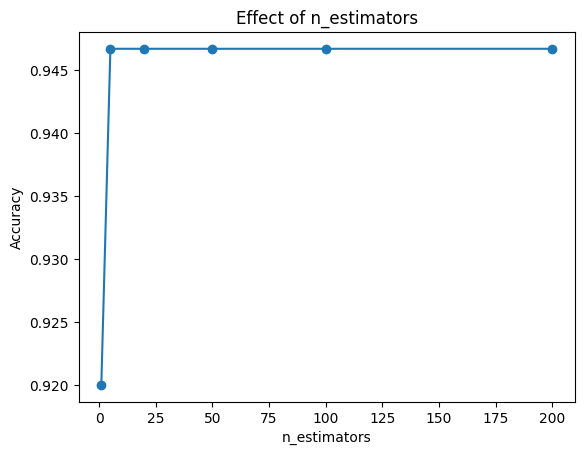

In [ ]:
estimators = [1, 5, 20, 50, 100, 200]
accuracies = []

for n in estimators:
    ada_temp = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=n,
        learning_rate=1.0
    )
    ada_temp.fit(X_train, y_train)
    acc = accuracy_score(y_test, ada_temp.predict(X_test))
    accuracies.append(acc)

plt.plot(estimators, accuracies, marker='o')
plt.title("Effect of n_estimators")
plt.xlabel("n_estimators")
plt.ylabel("Accuracy")
plt.show()


✔ More estimators → better accuracy (up to a point)

✔ Too many → may overfit noisy datasets

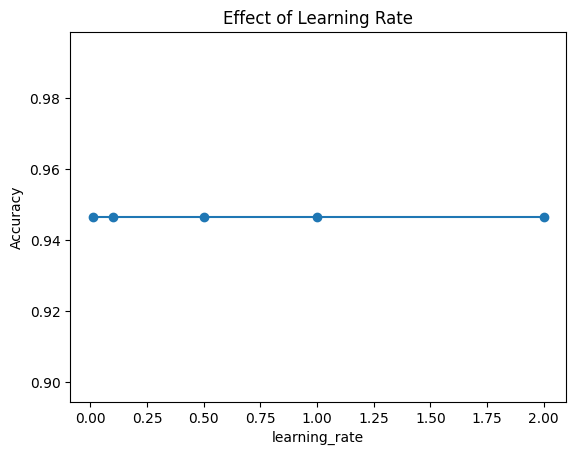

In [ ]:
rates = [0.01, 0.1, 0.5, 1, 2]
acc_lr = []

for lr in rates:
    ada_lr = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=100,
        learning_rate=lr
    )
    ada_lr.fit(X_train, y_train)
    acc_lr.append(accuracy_score(y_test, ada_lr.predict(X_test)))

plt.plot(rates, acc_lr, marker='o')
plt.title("Effect of Learning Rate")
plt.xlabel("learning_rate")
plt.ylabel("Accuracy")
plt.show()


Interpretation:

Small LR → slow learning → underfit

Large LR → aggressive learning → may overfit

Typically LR=0.1 to 1 works best

**Compare AdaBoost vs Random Forest vs Decision Tree**

In [ ]:
dt = DecisionTreeClassifier(max_depth=None)
dt.fit(X_train, y_train)

from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=200)
rf.fit(X_train, y_train)

print("Decision Tree Accuracy :", accuracy_score(y_test, dt.predict(X_test)))
print("Random Forest Accuracy :", accuracy_score(y_test, rf.predict(X_test)))
print("AdaBoost Accuracy      :", accuracy_score(y_test, ada.predict(X_test)))


Decision Tree Accuracy : 0.92
Random Forest Accuracy : 0.96
AdaBoost Accuracy      : 0.9466666666666667


Expected outcome:

Single Decision Tree → overfits → unstable

Random Forest → stable, low variance

AdaBoost → low bias, learns complex patterns

## 7. GradientBoost

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

np.random.seed(42)

# Class 0
x1_0 = np.random.normal(1, 1, 150)
x2_0 = np.random.normal(1, 1, 150)

# Class 1
x1_1 = np.random.normal(4, 1, 150)
x2_1 = np.random.normal(4, 1, 150)

X = np.vstack([np.column_stack([x1_0, x2_0]),
               np.column_stack([x1_1, x2_1])])
y = np.array([0]*150 + [1]*150)


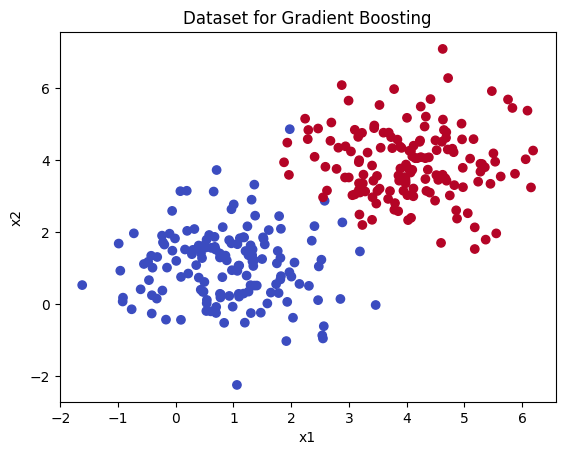

In [ ]:
plt.scatter(X[:,0], X[:,1], c=y, cmap="coolwarm")
plt.title("Dataset for Gradient Boosting")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)


In [ ]:
gb = GradientBoostingClassifier(
    n_estimators=100,    # number of boosting rounds
    learning_rate=0.1,   # shrinkage (step size)
    max_depth=3         # depth of each weak tree
)

gb.fit(X_train, y_train)

pred = gb.predict(X_test)
print("Gradient Boosting Accuracy:", accuracy_score(y_test, pred))


Gradient Boosting Accuracy: 0.96


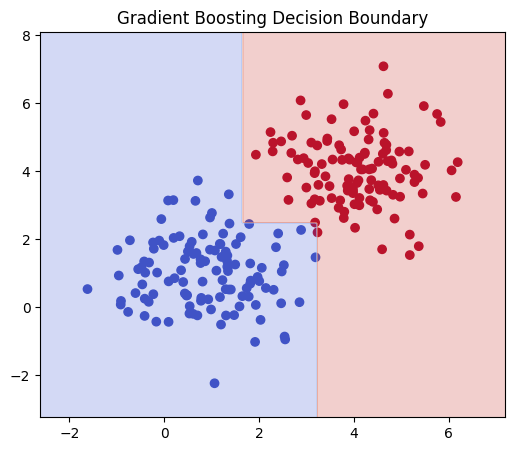

In [ ]:
def plot_boundary(model, X, y, title):
    plt.figure(figsize=(6,5))
    plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm')

    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

    xx, yy = np.meshgrid(
        np.linspace(x_min,x_max,200),
        np.linspace(y_min,y_max,200)
    )
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.25, cmap='coolwarm')
    plt.title(title)
    plt.show()

plot_boundary(gb, X_train, y_train, "Gradient Boosting Decision Boundary")


**Understand Residuals (manually for regression)**

In [ ]:
np.random.seed(42)
Xr = np.linspace(0, 10, 200).reshape(-1,1)
yr = 3*np.sin(Xr).ravel() + np.random.normal(0, 0.4, 200)


In [ ]:
F0 = np.full_like(yr, np.mean(yr))


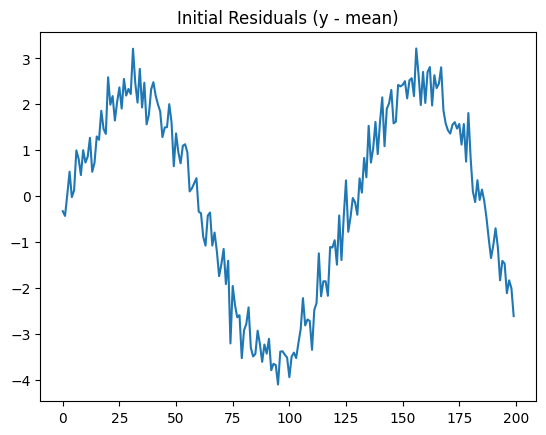

In [ ]:
residual = yr - F0
plt.plot(residual)
plt.title("Initial Residuals (y - mean)")
plt.show()


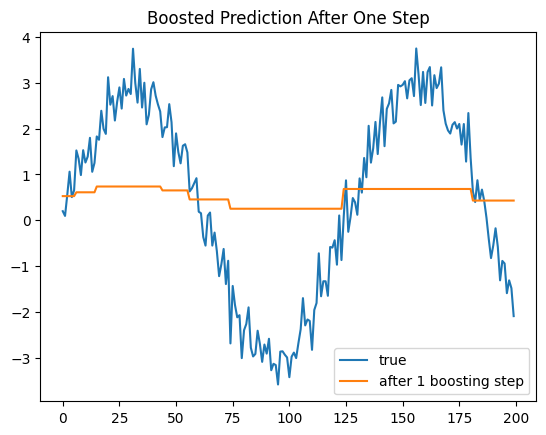

In [ ]:
stump = DecisionTreeRegressor(max_depth=3)
stump.fit(Xr, residual)
pred_res = stump.predict(Xr)
lr = 0.1
F1 = F0 + lr * pred_res
plt.plot(yr, label='true')
plt.plot(F1, label='after 1 boosting step')
plt.legend()
plt.title("Boosted Prediction After One Step")
plt.show()


✔ See how boosting gradually improves the fit

✔ This is the essence of gradient descent in function space

**Effect of learning_rate**

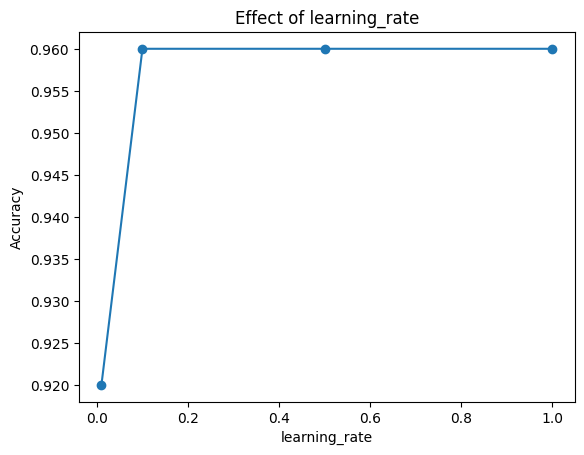

In [ ]:
rates = [0.01, 0.1, 0.5, 1]
accs = []

for r in rates:
    gb_lr = GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=r,
        max_depth=3
    )
    gb_lr.fit(X_train, y_train)
    accs.append(accuracy_score(y_test, gb_lr.predict(X_test)))

plt.plot(rates, accs, marker='o')
plt.title("Effect of learning_rate")
plt.xlabel("learning_rate")
plt.ylabel("Accuracy")
plt.show()


Interpretation:

Low LR → needs more estimators

High LR → faster learning, but may overfit

Usually 0.05–0.2 works best

**Effect of n_estimators**

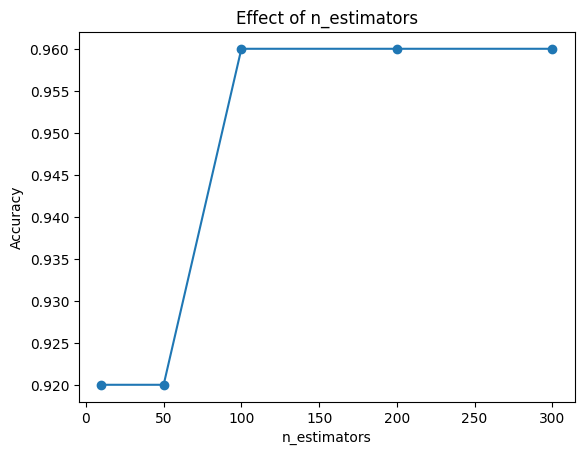

In [ ]:
estimators = [10, 50, 100, 200, 300]
acc_es = []

for n in estimators:
    gb_n = GradientBoostingClassifier(
        n_estimators=n,
        learning_rate=0.1,
        max_depth=3
    )
    gb_n.fit(X_train, y_train)
    acc_es.append(accuracy_score(y_test, gb_n.predict(X_test)))

plt.plot(estimators, acc_es, marker='o')
plt.title("Effect of n_estimators")
plt.xlabel("n_estimators")
plt.ylabel("Accuracy")
plt.show()


✔ More trees → better accuracy (until overfit)

**Effect of max_depth (controls bias)**

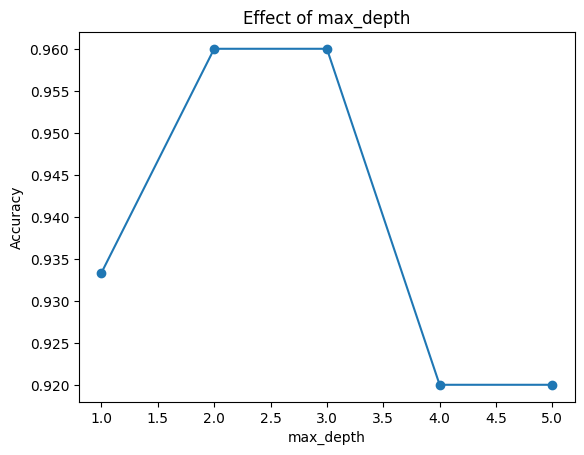

In [ ]:
depths = [1, 2, 3, 4, 5]
acc_depth = []

for d in depths:
    gb_d = GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=d
    )
    gb_d.fit(X_train, y_train)
    acc_depth.append(accuracy_score(y_test, gb_d.predict(X_test)))

plt.plot(depths, acc_depth, marker='o')
plt.title("Effect of max_depth")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.show()


✔ Depth=1 → high bias (weak corrections)

✔ Depth 3–4 → usually optimal

✔ Depth>5 → overfit

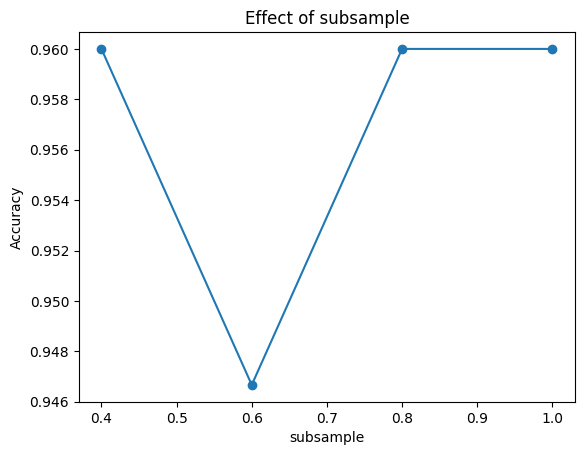

In [ ]:
subs = [1.0, 0.8, 0.6, 0.4]
acc_sub = []

for s in subs:
    gb_s = GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=3,
        subsample=s
    )
    gb_s.fit(X_train, y_train)
    acc_sub.append(accuracy_score(y_test, gb_s.predict(X_test)))

plt.plot(subs, acc_sub, marker='o')
plt.title("Effect of subsample")
plt.xlabel("subsample")
plt.ylabel("Accuracy")
plt.show()


✔ subsample < 1 = extra randomness

✔ reduces variance

✔ behaves like Random Forest + Boosting hybrid

**Compare Gradient Boosting vs Random Forest vs AdaBoost**

In [ ]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

rf = RandomForestClassifier(n_estimators=200)
rf.fit(X_train, y_train)

ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=200
)
ada.fit(X_train, y_train)

print("Random Forest Acc :", accuracy_score(y_test, rf.predict(X_test)))
print("AdaBoost Acc      :", accuracy_score(y_test, ada.predict(X_test)))
print("Gradient Boost Acc:", accuracy_score(y_test, gb.predict(X_test)))


Random Forest Acc : 0.9333333333333333
AdaBoost Acc      : 0.9466666666666667
Gradient Boost Acc: 0.96


## 8. XGBoost

In [ ]:
!pip install xgboost

import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

np.random.seed(42)

# Class 0
x1_0 = np.random.normal(1, 1, 150)
x2_0 = np.random.normal(1, 1, 150)

# Class 1
x1_1 = np.random.normal(4, 1, 150)
x2_1 = np.random.normal(4, 1, 150)

X = np.vstack([np.column_stack([x1_0, x2_0]),
               np.column_stack([x1_1, x2_1])])
y = np.array([0]*150 + [1]*150)


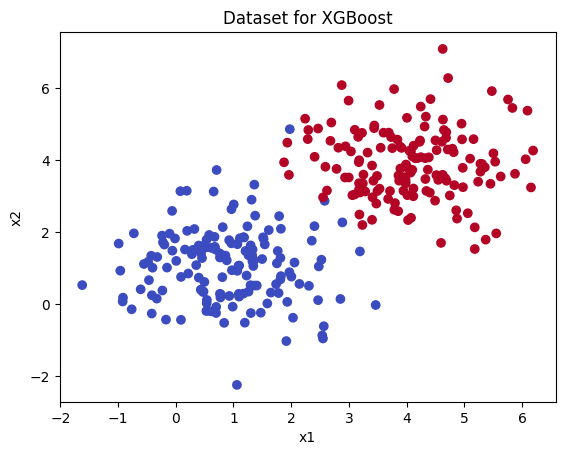

In [ ]:
plt.scatter(X[:,0], X[:,1], c=y, cmap="coolwarm")
plt.title("Dataset for XGBoost")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.1,
    subsample=1.0,
    colsample_bytree=1.0,
    eval_metric='logloss',
    use_label_encoder=False
)

xgb.fit(X_train, y_train)

pred = xgb.predict(X_test)
print("XGBoost Accuracy:", accuracy_score(y_test, pred))


XGBoost Accuracy: 0.9466666666666667


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [06:35:02] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


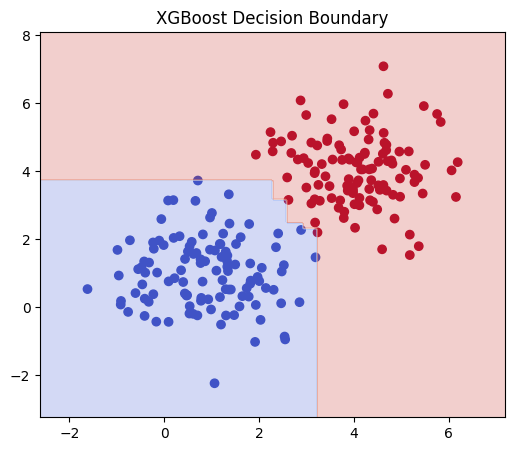

In [ ]:
def plot_boundary(model, X, y, title):
    plt.figure(figsize=(6,5))
    plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm')

    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1
    xx, yy = np.meshgrid(
        np.linspace(x_min,x_max,200),
        np.linspace(y_min,y_max,200)
    )
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.25, cmap='coolwarm')
    plt.title(title)
    plt.show()

plot_boundary(xgb, X_train, y_train, "XGBoost Decision Boundary")


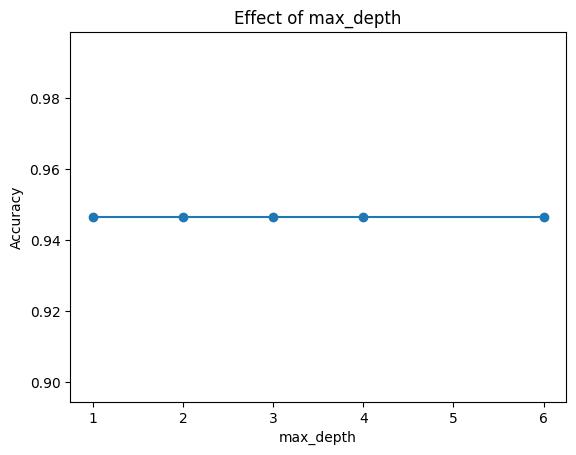

In [ ]:
depths = [1, 2, 3, 4, 6]
accs = []

for d in depths:
    model = XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=d,
        eval_metric="logloss"
    )
    model.fit(X_train, y_train)
    accs.append(accuracy_score(y_test, model.predict(X_test)))

plt.plot(depths, accs, marker='o')
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Effect of max_depth")
plt.show()


Interpretation:

Too shallow → underfits

Too deep → overfits

Depth 3–4 is usually best

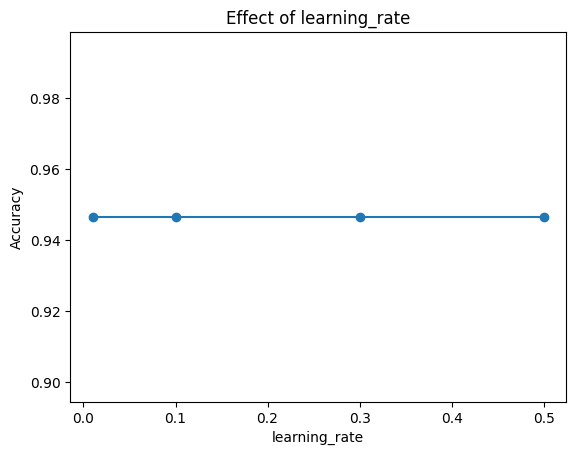

In [ ]:
rates = [0.01, 0.1, 0.3, 0.5]
acc_lr = []

for r in rates:
    model = XGBClassifier(
        n_estimators=200,
        learning_rate=r,
        max_depth=3,
        eval_metric="logloss"
    )
    model.fit(X_train, y_train)
    acc_lr.append(accuracy_score(y_test, model.predict(X_test)))

plt.plot(rates, acc_lr, marker='o')
plt.xlabel("learning_rate")
plt.ylabel("Accuracy")
plt.title("Effect of learning_rate")
plt.show()


✔ low LR → needs more trees

✔ high LR → aggressive, may overfit

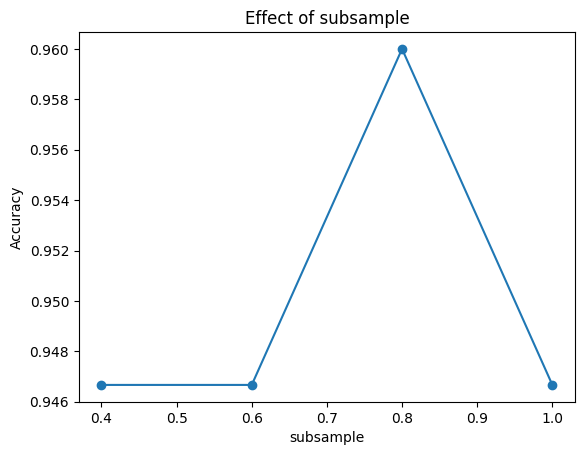

In [ ]:
subs = [1.0, 0.8, 0.6, 0.4]
acc_sub = []

for s in subs:
    model = XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=3,
        subsample=s,
        eval_metric="logloss"
    )
    model.fit(X_train, y_train)
    acc_sub.append(accuracy_score(y_test, model.predict(X_test)))

plt.plot(subs, acc_sub, marker='o')
plt.xlabel("subsample")
plt.ylabel("Accuracy")
plt.title("Effect of subsample")
plt.show()


✔ Acts like regularization

✔ Too low → underfits

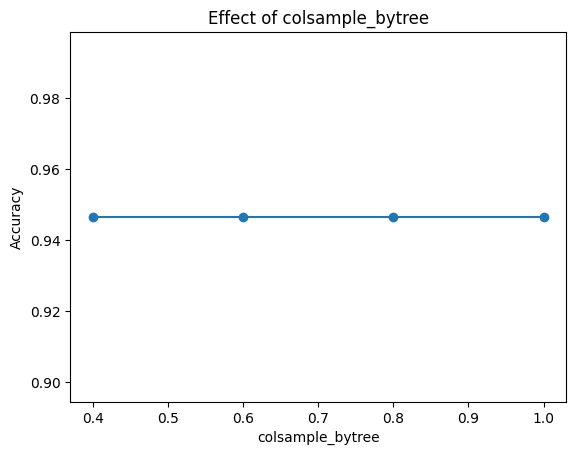

In [ ]:
cols = [1.0, 0.8, 0.6, 0.4]
acc_cols = []

for c in cols:
    model = XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=3,
        colsample_bytree=c,
        eval_metric="logloss"
    )
    model.fit(X_train, y_train)
    acc_cols.append(accuracy_score(y_test, model.predict(X_test)))

plt.plot(cols, acc_cols, marker='o')
plt.xlabel("colsample_bytree")
plt.ylabel("Accuracy")
plt.title("Effect of colsample_bytree")
plt.show()


✔ Helps reduce overfitting

✔ Similar to Random Forest-style feature sampling

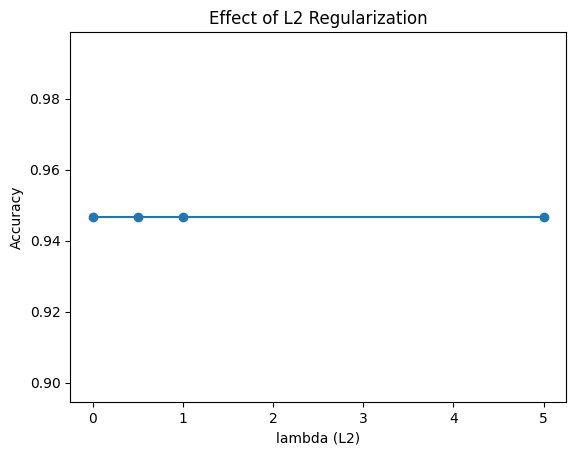

In [ ]:
lambdas = [0, 0.5, 1, 5]
acc_l2 = []

for l in lambdas:
    model = XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=3,
        reg_lambda=l,
        eval_metric="logloss"
    )
    model.fit(X_train, y_train)
    acc_l2.append(accuracy_score(y_test, model.predict(X_test)))

plt.plot(lambdas, acc_l2, marker='o')
plt.xlabel("lambda (L2)")
plt.ylabel("Accuracy")
plt.title("Effect of L2 Regularization")
plt.show()


✔ Regularization stabilizes model

✔ Helps prevent overfitting

**XGBoost with Early Stopping (important!)**

In [ ]:
model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    eval_metric="logloss",
    early_stopping_rounds=20  # Move it here
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

print("Best iteration:", model.best_iteration)

Best iteration: 100


This tells XGBoost to stop training early if the model doesn't improve for 20 consecutive iterations.

✔ Automatically stops when validation loss stops improving

✔ Prevents overfitting

✔ Saves training time

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, RandomForestClassifier

gbm = GradientBoostingClassifier(n_estimators=200).fit(X_train, y_train)
ada = AdaBoostClassifier(n_estimators=200).fit(X_train, y_train)
rf  = RandomForestClassifier(n_estimators=200).fit(X_train, y_train)

print("Random Forest      :", accuracy_score(y_test, rf.predict(X_test)))
print("AdaBoost           :", accuracy_score(y_test, ada.predict(X_test)))
print("Gradient Boosting  :", accuracy_score(y_test, gbm.predict(X_test)))
print("XGBoost            :", accuracy_score(y_test, model.predict(X_test)))


Random Forest      : 0.9733333333333334
AdaBoost           : 0.9466666666666667
Gradient Boosting  : 0.96
XGBoost            : 0.9466666666666667


# Unsupervised Techniques

## 1. Dimensionality Reduction & PCA

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

np.random.seed(42)
n = 500

# Two correlated core dimensions
x1 = np.random.normal(0, 1, n)
x2 = x1 * 0.75 + np.random.normal(0, 0.3, n)   # highly correlated

# Generate redundant features
x3 = x1 * 0.5 + np.random.normal(0, 0.5, n)
x4 = x2 * 0.8 + np.random.normal(0, 0.4, n)

X = np.column_stack([x1, x2, x3, x4])
df = pd.DataFrame(X, columns=['x1', 'x2', 'x3', 'x4'])
df.head()



,x1,x2,x3,x4
0,0.496714,0.650389,0.948035,0.831656
1,-0.138264,0.469127,0.393185,0.154827
2,0.647689,0.066196,0.353659,-0.274323
3,1.523030,1.311163,0.438047,1.047581
4,-0.234153,-0.370808,0.232035,-0.364720


**Visualize Feature Correlation**

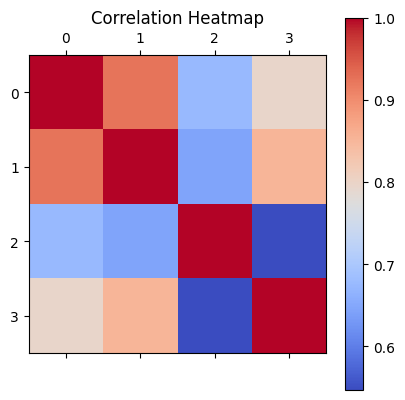

In [ ]:
plt.matshow(df.corr(), cmap='coolwarm')
plt.colorbar()
plt.title("Correlation Heatmap")
plt.show()


You’ll see strong correlations(x1 & x2) → PCA will compress these into fewer components.

**Standardize Features (IMPORTANT for PCA)**

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


✔ PCA requires mean=0, variance=1

✔ Avoids large-scale features dominating small-scale features

In [ ]:
pca = PCA()
pca.fit(X_scaled)

explained = pca.explained_variance_ratio_
explained


array([0.80922551, 0.12424193, 0.04986504, 0.01666752])

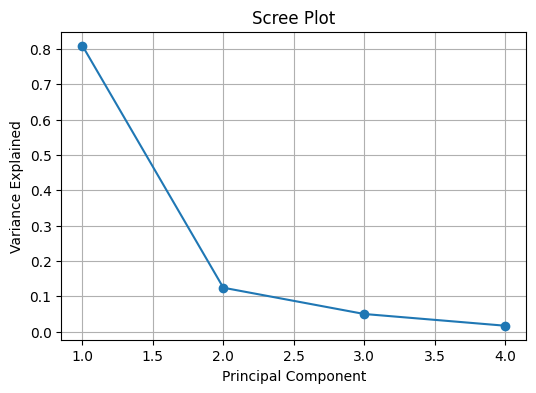

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(np.arange(1, 5), explained, marker='o')
plt.xlabel("Principal Component")
plt.ylabel("Variance Explained")
plt.title("Scree Plot")
plt.grid(True)
plt.show()


Interpretation:

PC1 explains most variance

PC2 explains less

PC3, PC4 explain very little → noise

This shows why dimensionality reduction makes sense.

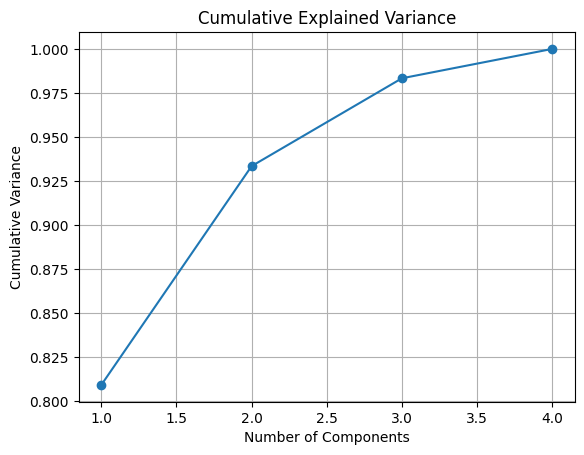

array([0.80922551, 0.93346744, 0.98333248, 1.        ])

In [ ]:
cum = np.cumsum(explained)

plt.plot(np.arange(1, 5), cum, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance")
plt.title("Cumulative Explained Variance")
plt.grid(True)
plt.show()

cum


If cum variance > 90% at 2 PCs → use k = 2

This matches theory: choose #PCs to retain 90–95% variance.

**Reduce Data to 2 Dimensions**

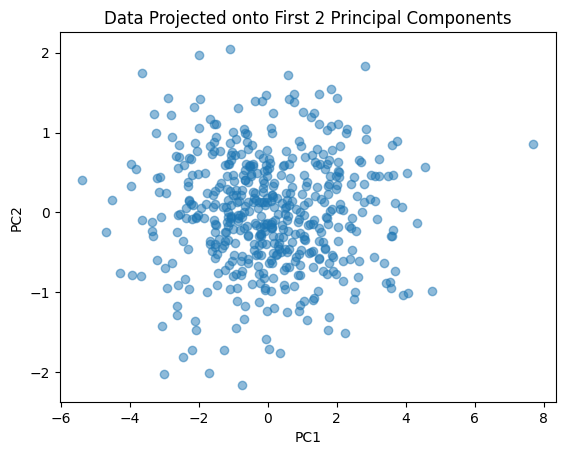

In [ ]:
pca_2 = PCA(n_components=2)
X_pca = pca_2.fit_transform(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.5)
plt.title("Data Projected onto First 2 Principal Components")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


PCA compresses the original 4D space into 2D while preserving most structure.

**Show Eigenvalues & Eigenvectors (Interview Essential)**

In [ ]:
print("Eigenvalues:", pca.explained_variance_)
print("\nEigenvectors (Principal Axes):\n", pca.components_)


Eigenvalues: [3.24338881 0.49796366 0.19985987 0.06680369]

Eigenvectors (Principal Axes):
 [[ 0.52863171  0.53322055  0.43473691  0.49722045]
 [-0.09802154 -0.21683685  0.87272111 -0.42629968]
 [-0.57083175 -0.29714286  0.22014251  0.73307197]
 [-0.62055733  0.76181608  0.02998258 -0.18342819]]


Eigenvectors tell:

How PCA rotates the data

Linear combination of original features

Directions of maximum variance

**Visualize PCA Rotation Effect**

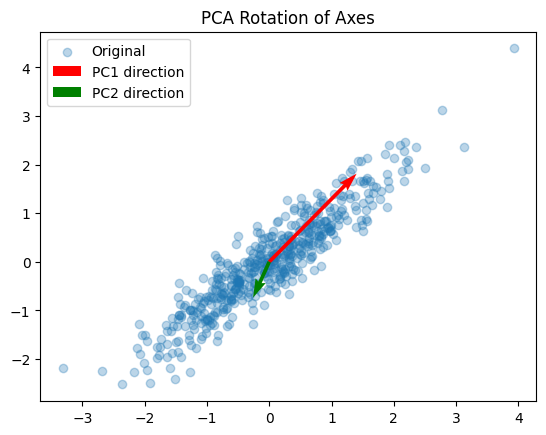

In [ ]:
plt.scatter(X_scaled[:,0], X_scaled[:,1], alpha=0.3, label="Original")
plt.quiver(0,0, pca.components_[0,0], pca.components_[0,1],
           color='r', scale=3, label='PC1 direction')
plt.quiver(0,0, pca.components_[1,0], pca.components_[1,1],
           color='g', scale=3, label='PC2 direction')
plt.title("PCA Rotation of Axes")
plt.legend()
plt.show()


You see how PCA finds new rotated axes (PC1, PC2) that capture variance better than original axes.

**Using PCA for Classification (Before vs After)**

In [ ]:
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X_iris, y_iris, test_size=0.3, random_state=42
)

lr = LogisticRegression(max_iter=500)
lr.fit(X_train, y_train)
pred1 = lr.predict(X_test)

print("Accuracy WITHOUT PCA:", accuracy_score(y_test, pred1))


Accuracy WITHOUT PCA: 1.0


Now apply PCA → reduce to 2D:

In [ ]:
pca = PCA(n_components=2)
X_pca_iris = pca.fit_transform(X_iris)

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_pca_iris, y_iris, test_size=0.3, random_state=42
)

lr2 = LogisticRegression(max_iter=500)
lr2.fit(X_train2, y_train2)
pred2 = lr2.predict(X_test2)

print("Accuracy WITH PCA (2 components):", accuracy_score(y_test2, pred2))


Accuracy WITH PCA (2 components): 1.0


Interpretation:

PCA reduces dimensionality

Accuracy may drop slightly

But training becomes faster, and model becomes simpler

On high-dimensional data, PCA gives big benefits

## 2. K-Means

In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (6,4)

In [ ]:
X, y_true = make_blobs(n_samples=1000, centers=4, cluster_std=[0.8, 0.6, 1.0, 0.5], random_state=42)
df = pd.DataFrame(X, columns=['x1','x2'])
df

,x1,x2
0,-8.696684,7.194070
1,-6.137532,-6.580817
2,-6.321300,-6.804104
3,4.364262,1.463263
4,4.484124,1.071284
...,...,...
995,-4.818124,-5.671743
996,-2.009902,9.516963
997,4.070240,3.552599
998,-7.489139,-7.067081


**Preprocess: always scale continuous features**

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
X_scaled

array([[-1.02312574,  0.69042454],
       [-0.53198467, -1.52245299],
       [-0.5672527 , -1.55832313],
       ...,
       [ 1.4270454 ,  0.10543751],
       [-0.79137919, -1.60056923],
       [-1.10425381,  0.69441523]])

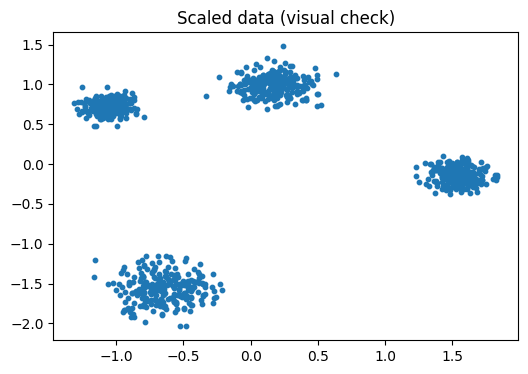

In [ ]:
plt.scatter(X_scaled[:,0], X_scaled[:,1], s=10)
plt.title("Scaled data (visual check)")
plt.show()

**Choose K: Elbow + Silhouette quick scan**

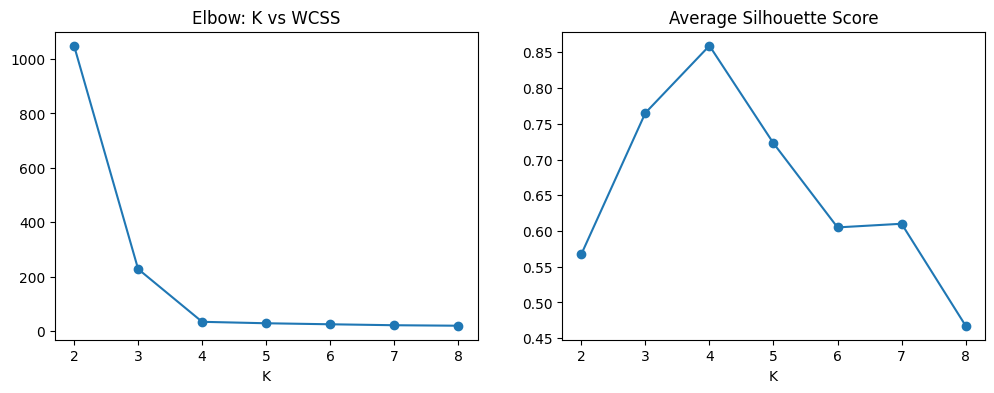

In [ ]:
ks = range(2,9)
wcss = []
sil = []
for k in ks:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_scaled)
    wcss.append(km.inertia_)                 # WCSS
    sil.append(silhouette_score(X_scaled, km.labels_))

# Plot
fig, ax = plt.subplots(1,2, figsize=(12,4))
ax[0].plot(ks, wcss, marker='o')
ax[0].set_title("Elbow: K vs WCSS")
ax[0].set_xlabel("K")

ax[1].plot(ks, sil, marker='o')
ax[1].set_title("Average Silhouette Score")
ax[1].set_xlabel("K")
plt.show()


**Fit K-Means with K chosen (use KMeans++ and n_init)**

Why: k-means++  &  n_init>1 reduces bad local optima risk(intializing random centroids). Interviewers expect n_init mention.

In [ ]:
best_k = 4  # choose based on previous plots / reasoning
km = KMeans(n_clusters=best_k, init='k-means++', n_init=20, random_state=0)
labels = km.fit_predict(X_scaled)

In [ ]:
print("WCSS (inertia):", km.inertia_)
print("Silhouette score:", silhouette_score(X_scaled, labels))
print("Davies-Bouldin:", davies_bouldin_score(X_scaled, labels))
print("Calinski-Harabasz:", calinski_harabasz_score(X_scaled, labels))


WCSS (inertia): 34.35036382296331
Silhouette score: 0.8592931001209442
Davies-Bouldin: 0.19357021332033042
Calinski-Harabasz: 18998.217386405504


**Visualize clusters + centroids (2D)**

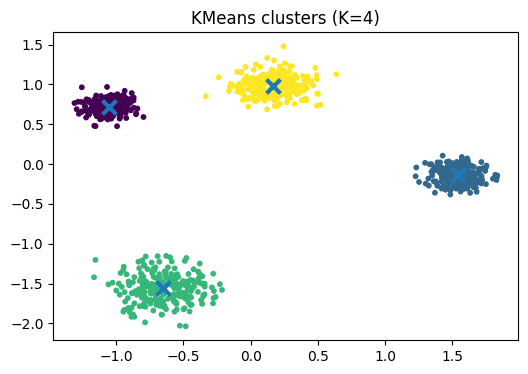

In [ ]:
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels, s=10)
centers = km.cluster_centers_
plt.scatter(centers[:,0], centers[:,1], marker='x', s=100, linewidths=3)
plt.title(f"KMeans clusters (K={best_k})")
plt.show()


**Inspect borderline points using per-point silhouette (useful in interviews)**

Why: Shows you can diagnose borderline/misclustered points — great interview talking point.

In [ ]:
from sklearn.metrics import silhouette_samples
samp_sil = silhouette_samples(X_scaled, labels)
df_out = pd.DataFrame({'x1': X_scaled[:,0], 'x2': X_scaled[:,1], 'label': labels, 'sil': samp_sil})
# show worst-fitting points in each cluster
for k in range(best_k):
    worst = df_out[df_out['label']==k].nsmallest(3, 'sil')
    print(f"Cluster {k} worst samples (silhouette):")
    print(worst[['x1','x2','sil']])


Cluster 0 worst samples (silhouette):
           x1        x2       sil
45  -0.796564  0.590498  0.712425
387 -0.884061  0.890445  0.757203
55  -1.255244  0.963254  0.766767
Cluster 1 worst samples (silhouette):
           x1        x2       sil
623  1.231111 -0.043084  0.771584
967  1.225823 -0.153524  0.788398
601  1.296635  0.015226  0.794500
Cluster 2 worst samples (silhouette):
           x1        x2       sil
426 -1.154079 -1.202503  0.664296
294 -1.164542 -1.420439  0.735847
334 -0.780314 -1.159569  0.756524
Cluster 3 worst samples (silhouette):
           x1        x2       sil
569 -0.333291  0.851184  0.277942
103 -0.237867  1.088463  0.514217
519 -0.161738  0.915266  0.607617


**Production note: MiniBatch KMeans (scale to large data)**

Why: For millions of rows, MiniBatch is faster and memory-friendly; mention tradeoffs (slightly noisier results).

In [ ]:
mbkm = MiniBatchKMeans(n_clusters=best_k, init='k-means++', batch_size=1000, random_state=42)
mb_labels = mbkm.fit_predict(X_scaled)
print("MiniBatch silhouette:", silhouette_score(X_scaled, mb_labels))

MiniBatch silhouette: 0.8592931001209442


# Short interview script (what to say when asked to implement)

1. I’ll standardize numeric features because K-Means uses Euclidean distance.

2. I’ll run Elbow + Silhouette to select candidate K; choose the K that balances compactness and separability.

3. I’ll fit KMeans with init='k-means++' and n_init=10-20 to avoid poor seeds.

4. I’ll validate with silhouette and DB index and visually inspect clusters.

5. For production on large data, I’d use MiniBatchKMeans or sample+refit; I’d persist centroids and score new points by nearest centroid.

6. I’d interpret clusters into personas and A/B test messages within each persona. I’d look at uplift per cluster and measure statistically.

# Mini checklist you can memorize & say in interviews

1. Standardize data → StandardScaler()
2. Use init='k-means++' and n_init > 1
3. Use Elbow + Silhouette to pick K (report both)
4. Inspect per-point silhouette for outliers/bad points
5. For scale → MiniBatchKMeans; for categorical → K-modes
6. Always validate business sense & run A/B tests

## 3. Hierarchical Clustering

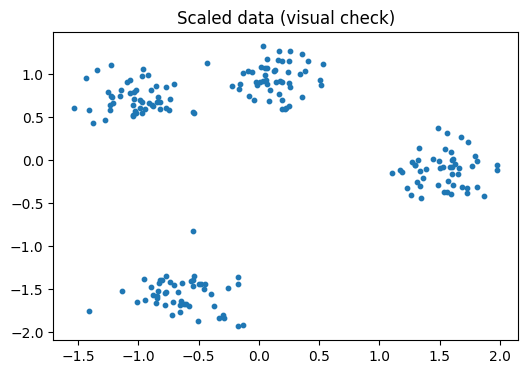

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Create sample data
X, y = make_blobs(n_samples=200, centers=4, random_state=42, cluster_std=1.2)

# Scale data (important for distance-based clustering)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], s=10)
plt.title("Scaled data (visual check)")
plt.show()


In [ ]:
model = AgglomerativeClustering(n_clusters=4, linkage='ward') #n_clusters=4: number of clusters we want (you can also decide later via dendrogram)
labels = model.fit_predict(X_scaled)

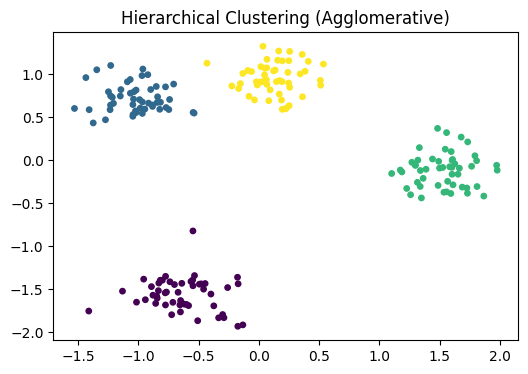

In [ ]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='viridis', s=15)
plt.title("Hierarchical Clustering (Agglomerative)")
plt.show()


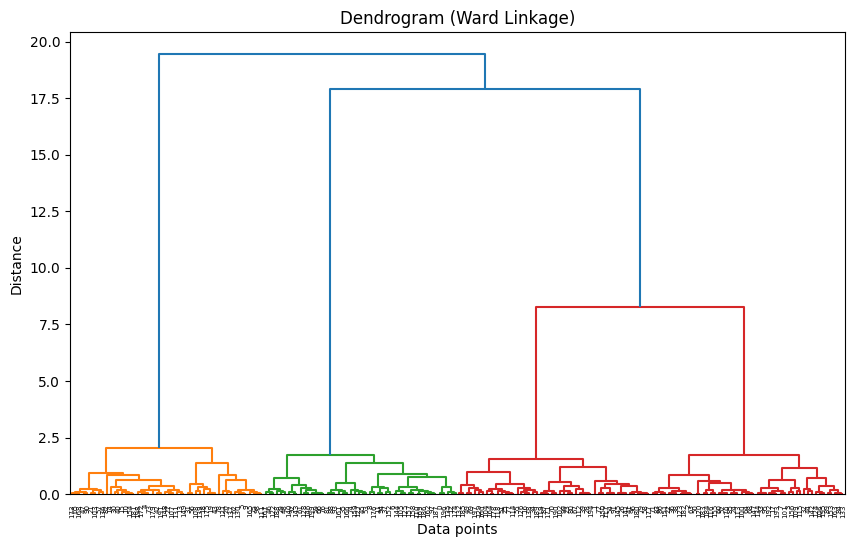

In [ ]:
Z = linkage(X_scaled, method='ward')  # Ward linkage again
plt.figure(figsize=(10, 6))
dendrogram(Z)
plt.title("Dendrogram (Ward Linkage)")
plt.xlabel("Data points")
plt.ylabel("Distance")
plt.show()


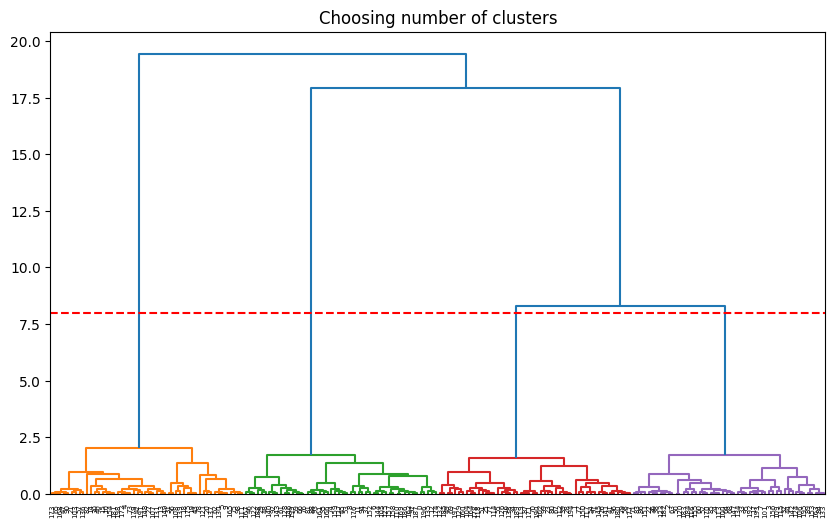

In [ ]:
plt.figure(figsize=(10,6))
dendrogram(Z, color_threshold=8)  # 8 is an example cutoff
plt.axhline(y=8, color='r', linestyle='--')
plt.title("Choosing number of clusters")
plt.show()


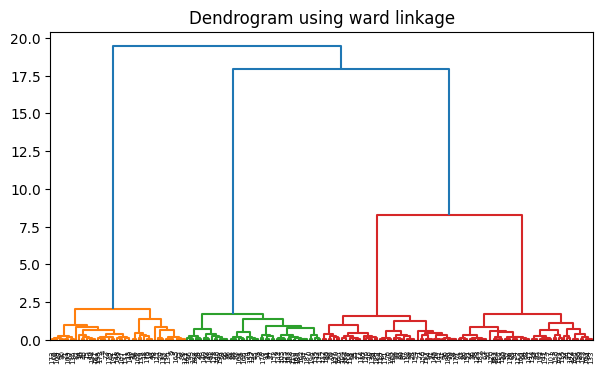

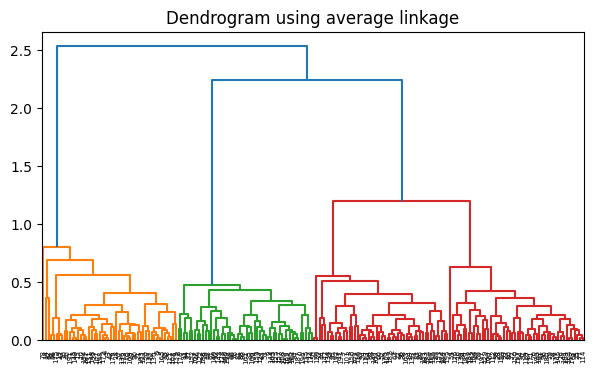

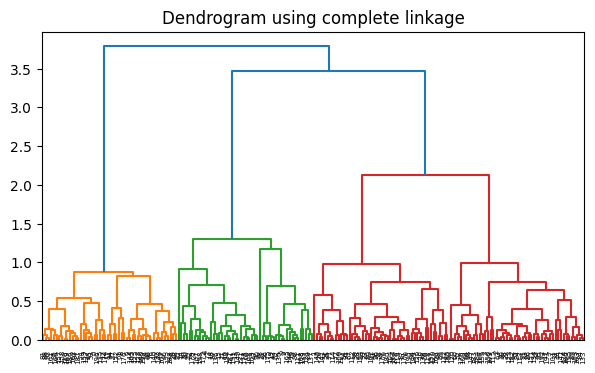

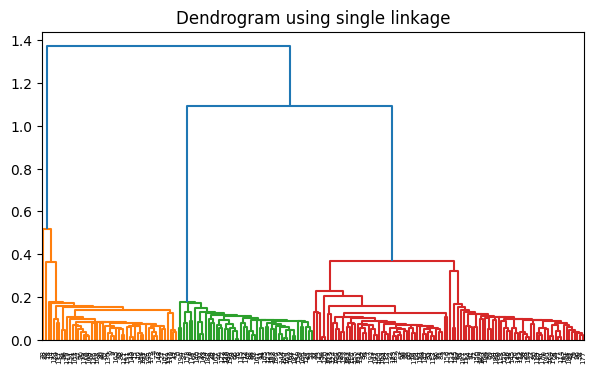

In [ ]:
methods = ['ward', 'average', 'complete', 'single']

for m in methods:
    Z = linkage(X_scaled, method=m)
    plt.figure(figsize=(7,4))
    dendrogram(Z)
    plt.title(f"Dendrogram using {m} linkage")
    plt.show()


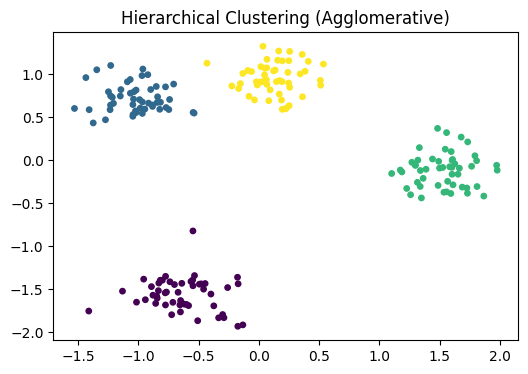

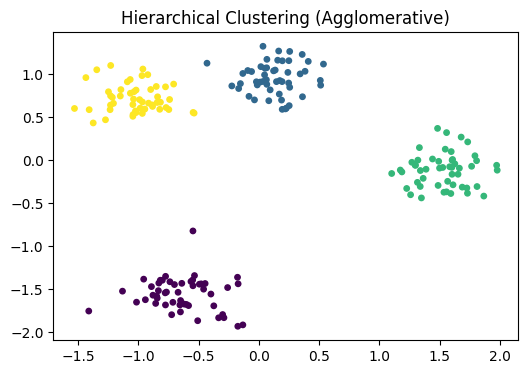

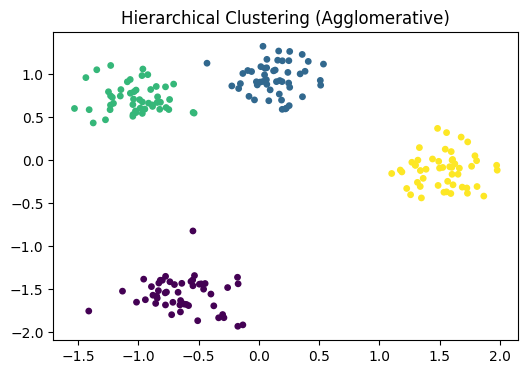

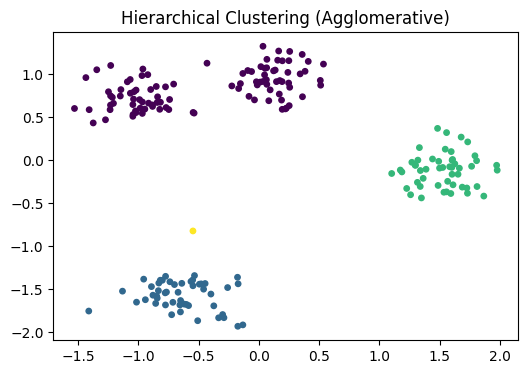

In [ ]:
linkage = ['ward', 'average', 'complete', 'single']

for l in linkage:
  model = AgglomerativeClustering(n_clusters=4, linkage=l)
  labels = model.fit_predict(X_scaled)
  plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='viridis', s=15)
  plt.title("Hierarchical Clustering (Agglomerative)")
  plt.show()

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

kmeans = KMeans(n_clusters=4, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

model = AgglomerativeClustering(n_clusters=4, linkage='ward')
labels = model.fit_predict(X_scaled)

print("KMeans Silhouette:", silhouette_score(X_scaled, kmeans_labels))
print("Hierarchical Silhouette:", silhouette_score(X_scaled, labels))


KMeans Silhouette: 0.7598123471293373
Hierarchical Silhouette: 0.7598123471293373


## 3. DBSCAN

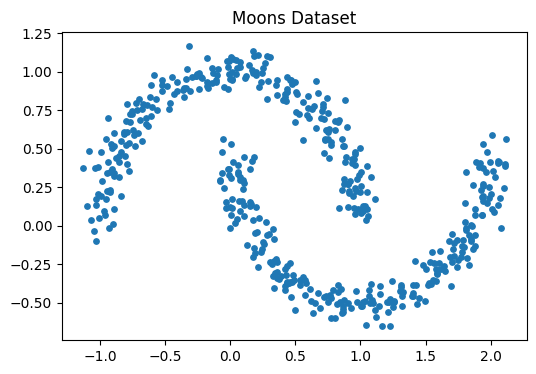

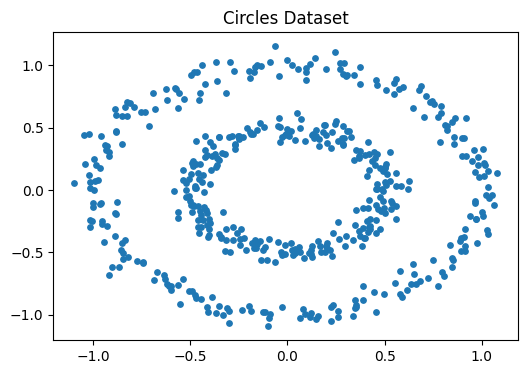

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons, make_circles, make_blobs
from sklearn.neighbors import NearestNeighbors

#Moons (non-linear, perfect for DBSCAN)

X_moons, _ = make_moons(n_samples=500, noise=0.07, random_state=42)

plt.scatter(X_moons[:,0], X_moons[:,1], s=15)
plt.title("Moons Dataset")
plt.show()

#Circles (KMeans fails; DBSCAN succeeds)

X_circles, _ = make_circles(n_samples=500, noise=0.05, factor=0.5, random_state=42)

plt.scatter(X_circles[:,0], X_circles[:,1], s=15)
plt.title("Circles Dataset")
plt.show()



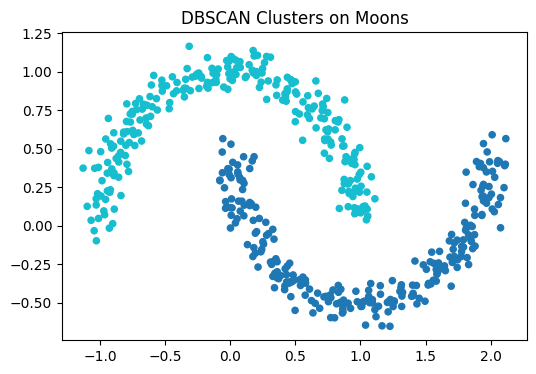

In [ ]:
db = DBSCAN(eps=0.2, min_samples=5)
labels = db.fit_predict(X_moons)

plt.scatter(X_moons[:,0], X_moons[:,1], c=labels, cmap='tab10', s=20)
plt.title("DBSCAN Clusters on Moons")
plt.show()


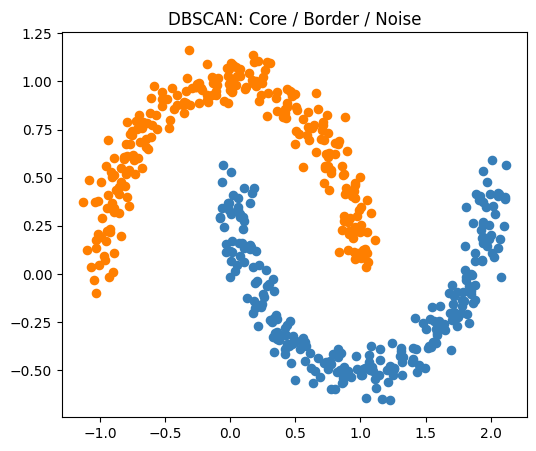

In [ ]:
core_samples = db.core_sample_indices_
labels = db.fit_predict(X_moons)

colors = np.array(['#377eb8','#ff7f00','#4daf4a','#984ea3',
                   '#e41a1c','#f781bf','#a65628','#999999'])

plt.figure(figsize=(6,5))
unique_labels = set(labels)
for k in unique_labels:
    class_member_mask = (labels == k)

    if k == -1:
        # Noise
        col = 'k'
        size = 20
    else:
        col = colors[k % len(colors)]
        size = 35

    plt.scatter(X_moons[class_member_mask, 0],
                X_moons[class_member_mask, 1],
                c=col, s=size)

plt.title("DBSCAN: Core / Border / Noise")
plt.show()


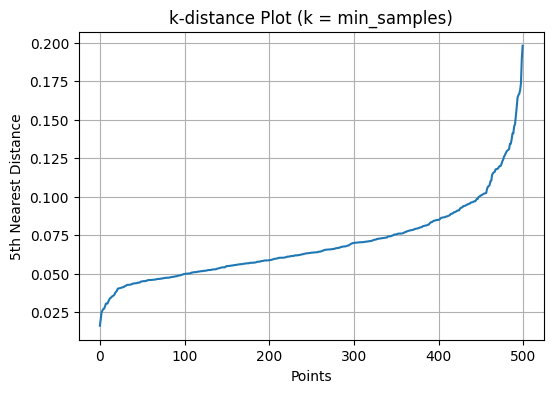

In [ ]:
neigh = NearestNeighbors(n_neighbors=5)
neigh.fit(X_moons)
distances, _ = neigh.kneighbors(X_moons)

distances = np.sort(distances[:,4])   # distance to 5th nearest neighbor

plt.plot(distances)
plt.title("k-distance Plot (k = min_samples)")
plt.xlabel("Points")
plt.ylabel("5th Nearest Distance")
plt.grid(True)
plt.show()


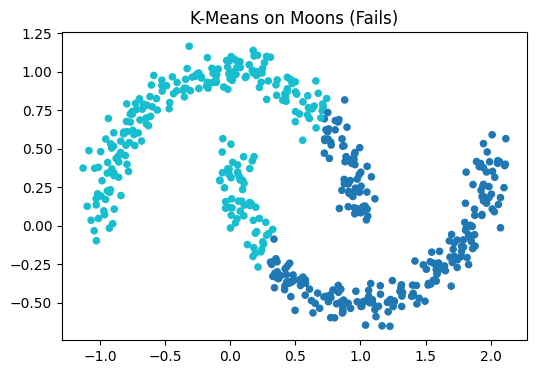

In [ ]:
from sklearn.cluster import KMeans

km = KMeans(n_clusters=2, random_state=42)
km_labels = km.fit_predict(X_moons)

plt.scatter(X_moons[:,0], X_moons[:,1], c=km_labels, cmap='tab10', s=20)
plt.title("K-Means on Moons (Fails)")
plt.show()


🎯 KMeans fails. DBSCAN wins.

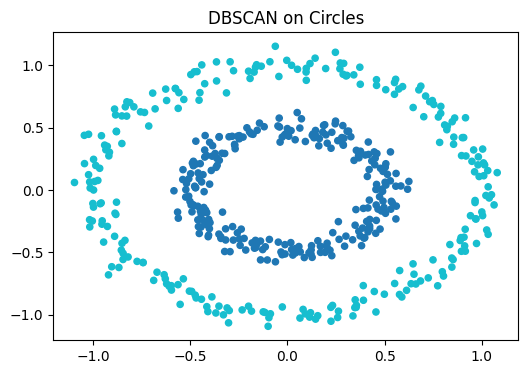

In [ ]:
db2 = DBSCAN(eps=0.15, min_samples=5)
labels2 = db2.fit_predict(X_circles)

plt.scatter(X_circles[:,0], X_circles[:,1], c=labels2, cmap='tab10', s=20)
plt.title("DBSCAN on Circles")
plt.show()


**DBSCAN Failure Case: Varying Densities**

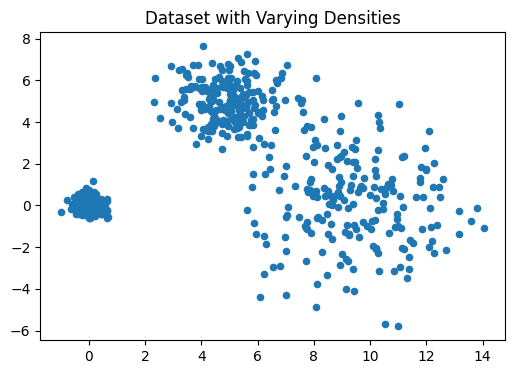

In [ ]:
X_var, _ = make_blobs(
    n_samples=[200, 200, 200],
    centers=[[0,0],[5,5],[9,0]],
    cluster_std=[0.3, 1.0, 2.0],   # varying densities
    random_state=42
)

plt.scatter(X_var[:,0], X_var[:,1], s=20)
plt.title("Dataset with Varying Densities")
plt.show()


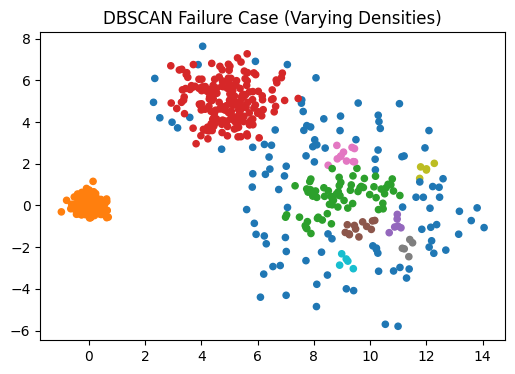

In [ ]:
db3 = DBSCAN(eps=0.5, min_samples=5)
labels3 = db3.fit_predict(X_var)

plt.scatter(X_var[:,0], X_var[:,1], c=labels3, cmap='tab10', s=20)
plt.title("DBSCAN Failure Case (Varying Densities)")
plt.show()


🎯 DBSCAN fails because one cluster is dense and another is sparse.
That’s why HDBSCAN is used in industry.

## 4. GMM

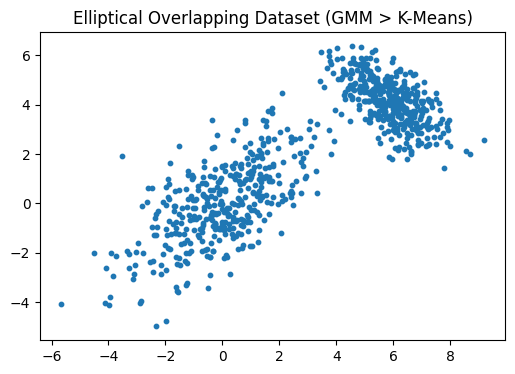

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Elliptical, rotated clusters with different densities
np.random.seed(42)

cov1 = [[3, 2], [2, 3]]      # strongly elliptical
cov2 = [[1, -0.7], [-0.7, 1]]  # tilted ellipse

X1 = np.random.multivariate_normal(mean=[0, 0], cov=cov1, size=400)
X2 = np.random.multivariate_normal(mean=[6, 4], cov=cov2, size=400)

X = np.vstack([X1, X2])

plt.scatter(X[:,0], X[:,1], s=10)
plt.title("Elliptical Overlapping Dataset (GMM > K-Means)")
plt.show()


**Run K-Means (for comparison)**

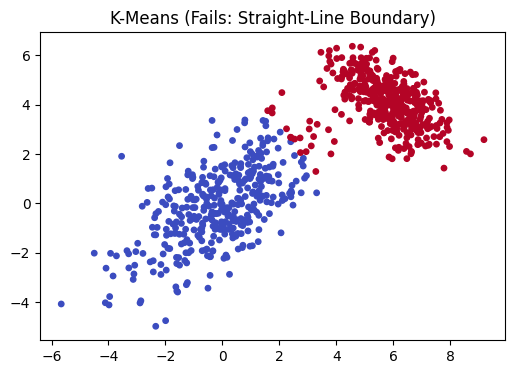

In [ ]:
from sklearn.cluster import KMeans

km = KMeans(n_clusters=2, random_state=42)
km_labels = km.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=km_labels, cmap="coolwarm", s=15)
plt.title("K-Means (Fails: Straight-Line Boundary)")
plt.show()


K-Means draws a straight linear boundary

It completely ignores the elliptical shape

Misclassifies many overlapping points

Boundary is wrong because K-Means only models means, not covariances

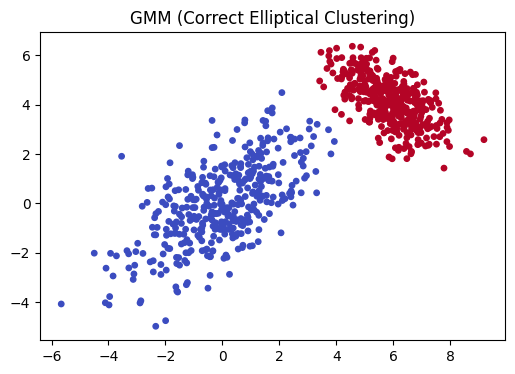

In [ ]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=2, covariance_type="full", random_state=42)
gmm_labels = gmm.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=gmm_labels, cmap="coolwarm", s=15)
plt.title("GMM (Correct Elliptical Clustering)")
plt.show()


GMM draws curved, elliptical boundaries

Perfectly fits the true shape of clusters

Fewer misclassifications

GMM understands covariance, so it adapts the shape

**Visualize Soft Probabilities (GMM’s superpower)**

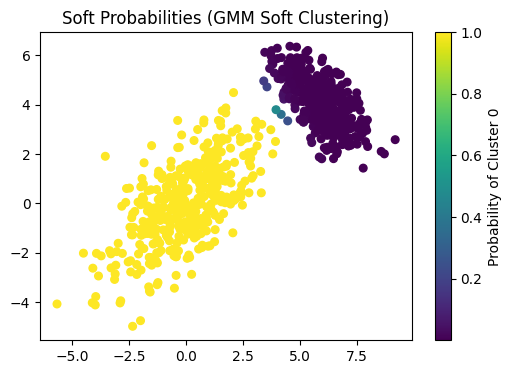

In [ ]:
probs = gmm.predict_proba(X)

plt.scatter(X[:,0], X[:,1], c=probs[:,0], cmap="viridis", s=30)
plt.colorbar(label="Probability of Cluster 0")
plt.title("Soft Probabilities (GMM Soft Clustering)")
plt.show()


Interpretation

Values close to 1.0 → almost definitely Cluster 0

Values close to 0.0 → almost definitely Cluster 1

Values ~0.5 → overlapping region

This is why GMM is better than K-Means.

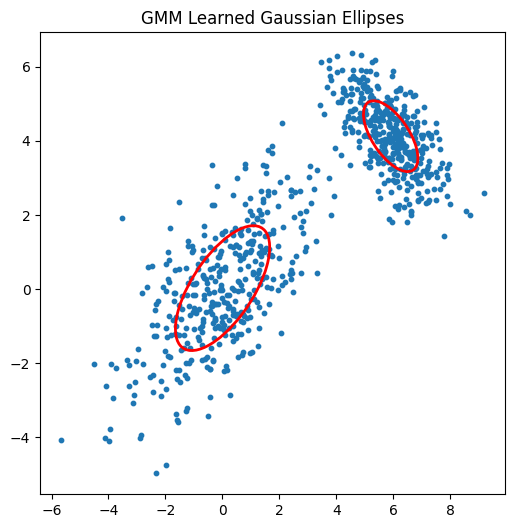

In [ ]:
def draw_ellipse(mean, cov, ax, color):
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    order = eigenvalues.argsort()[::-1]
    eigenvalues, eigenvectors = eigenvalues[order], eigenvectors[:, order]

    angle = np.degrees(np.arctan2(*eigenvectors[:,0][::-1]))
    width, height = 2 * np.sqrt(eigenvalues)

    from matplotlib.patches import Ellipse
    ellipse = Ellipse(
        xy=mean,
        width=width,
        height=height,
        angle=angle,              # <-- FIXED here
        edgecolor=color,
        facecolor='none',
        lw=2
    )
    ax.add_patch(ellipse)

fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(X[:,0], X[:,1], s=10)

for i in range(2):
    draw_ellipse(gmm.means_[i], gmm.covariances_[i], ax, color="red")

plt.title("GMM Learned Gaussian Ellipses")
plt.show()


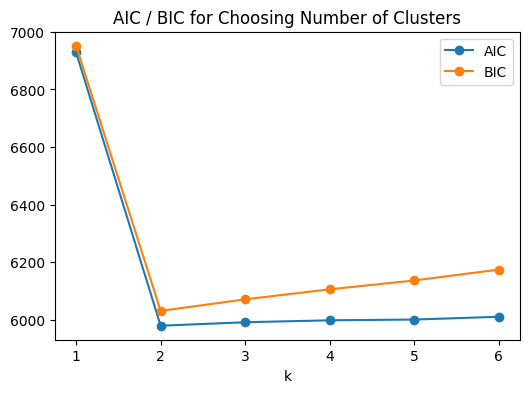

In [ ]:
aics = []
bics = []
components = range(1, 7)

for k in components:
    gmm_k = GaussianMixture(n_components=k, covariance_type="full", random_state=42).fit(X)
    aics.append(gmm_k.aic(X))
    bics.append(gmm_k.bic(X))

plt.plot(components, aics, marker='o', label="AIC")
plt.plot(components, bics, marker='o', label="BIC")
plt.title("AIC / BIC for Choosing Number of Clusters")
plt.xlabel("k")
plt.legend()
plt.show()


Pick the k where AIC/BIC is lowest.
Usually BIC → more conservative

**GMM for Anomaly Detection**

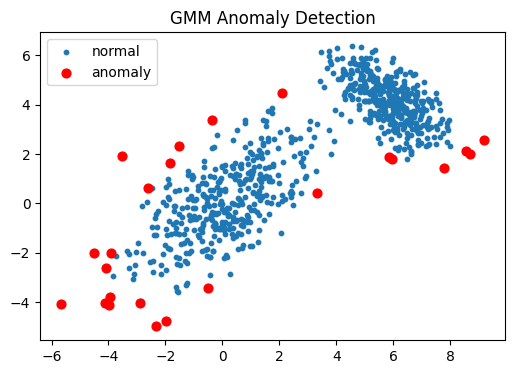

In [ ]:
# compute log-likelihood under GMM
scores = gmm.score_samples(X)
threshold = np.percentile(scores, 3)   # bottom 3% = anomalies

anomalies = X[scores < threshold]

plt.scatter(X[:,0], X[:,1], s=10, label="normal")
plt.scatter(anomalies[:,0], anomalies[:,1], c="red", s=40, label="anomaly")
plt.legend()
plt.title("GMM Anomaly Detection")
plt.show()


Points with very low probability under all Gaussians are anomalies.